<div align="center">

# Notebook 5 MERT V1 Fine Tune 

# Classification multi-class FOCH

**Branche Dual pour la classification**

![Python](https://img.shields.io/badge/Python-3.10+-blue?style=flat-square&logo=python)
![PyTorch](https://img.shields.io/badge/PyTorch-2.0+-EE4C2C?style=flat-square&logo=pytorch)
![HuggingFace](https://img.shields.io/badge/🤗-Transformers-FFD21F?style=flat-square)
![CUDA](https://img.shields.io/badge/CUDA-AMP%20Enabled-76B900?style=flat-square&logo=nvidia)

</div>


## Synthèse de l'architecture configurable (upgrade notebook 5)

Cet upgrade rend l'architecture **entièrement pilotable par configuration**, pour comparer plusieurs backbones audio-domaine *sans réécrire la boucle d'entraînement*. Cible : battre la baseline du notebook 5 (**CNN14, 75.2 %, K=5 CV**).

**1 — Backbone configurable (`BACKBONE`, Cellule 1).** Un preset unique sélectionne la/les branche(s) ; la tête de fusion s'adapte automatiquement à la dimension d'embedding, et `forward(input_values, spec)` reste inchangé.

| Preset | Branche audio-domaine (AudioSet) | Branche WavLM | Fusion |
|---|---|---|---|
| `cnn14` *(défaut)* | CNN14 entraînable (2048-d) | WavLM-Base gelé (768-d) | 2816-d |
| `ast` | AST gelé (768-d) | WavLM-Base gelé (768-d) | 1536-d |
| `cnn14_solo` / `ast_solo` | CNN14 / AST seul | — | 2048 / 768-d |
| `wavlm_base` / `wavlm_large` | — | WavLM Base / Large gelé | 768 / 1024-d |

**2 — Gel de WavLM.** Gelé par défaut (`FREEZE_WAVLM=True`, config du meilleur résultat). **Dégel tardif et partiel** optionnel (`UNFREEZE_ENABLED`) : uniquement les `UNFREEZE_LAST_N` dernières couches, à partir de l'époque `UNFREEZE_AT_EPOCH` (≥ 20), à LR discriminant réduit — un petit jeu (~265 enregistrements) ne peut pas remodeler 95–300M paramètres sans dégrader la baseline gelée.

**3 — AST + budget mémoire.** AST chargé **en local** (`ast-finetuned-audioset-10-10-0.4593`), gelé, avec un fbank interne fixe (1024×128) indépendant de la fenêtre. L'arbitrage **fenêtre ↔ batch** est absorbé par l'accumulation de gradient (batch effectif ≈ 16) ; la **sonde VRAM (Cellule 6b)** dimensionne `BATCH_SIZE` — mesuré ≈ 0.27 Go/éch. (`cnn14`+WavLM-Base) → 8 Go : `BATCH_SIZE` 8 ; RTX 5070 Ti 16 Go : 16-24.

**4 — Tête de classification cosinus (`CosineClassifierHead`, Cellule 6a).** Remplace le `nn.Linear(HIDDEN_DIM, NUM_LABELS)` final par une couche à similarité cosinus (ArcFace/CosFace). Motivation : la confusion out-of-fold la plus importante (`fuite glottique` ↔ `PR`, 15/26 mal classés, contre 4/26 vers `LMB`) est concentrée sur une seule paire de classes plutôt que diffuse — viser une meilleure séparation **angulaire** dans l'espace de fusion plutôt qu'un rééquilibrage de perte qui affecterait les 4 classes uniformément. Marge additive optionnelle (`USE_ANGULAR_MARGIN`) appliquée uniquement pendant l'entraînement (labels requis, `forward(input_values, spec, labels=None)`) ; à l'inférence, retombe sur un softmax cosinus pur. Nouveaux réglages (Cellule 1) : `COSINE_SCALE=30.0`, `USE_ANGULAR_MARGIN=True`, `ANGULAR_MARGIN=0.2` (réduite vs. le défaut ArcFace 0.5, jugé trop agressif sur ~500 échantillons). Smoke test dédié en Cellule 6c, à exécuter avant de relancer la CV complète.

> Les explications détaillées accompagnent chaque section (Cellules 1, 6, 6a, 6b, 6c, 7).

## 1. Configuration de l'environnement et des chemins

Cette première section centralise les dépendances, les chemins **et la sélection du backbone**. Le notebook met en œuvre un **classifieur multi-branche configurable** évalué par **validation croisée stratifiée à 5 plis** (`StratifiedKFold`), avec **augmentation de données injectée pli par pli dans le seul jeu d'entraînement**.

**Classes retenues :**

| Classe | Origine | Justification |
|---|---|---|
| `PR` | FOCH | Pathologie majoritaire (support le plus élevé) |
| `LMB` | FOCH | Support intermédiaire |
| `fuite glottique` | FOCH | Support intermédiaire |
| `Healthy` | Saarbruecken (SVD) | Groupe contrôle — voyelle /a/ à hauteur habituelle |

La classe `Cancer` reste **exclue** (support insuffisant, n ≈ 26). Le déséquilibre des trois pathologies est compensé par des **signaux augmentés** injectés **exclusivement dans le train de chaque pli** ; le pli de validation reste strictement original.

### Sélection configurable du backbone (`BACKBONE`)

Le problème est plus proche de l'**analyse bioacoustique / de signal pathologique** que de la reconnaissance de parole ; on privilégie donc des backbones **audio-domaine pré-entraînés sur AudioSet** plutôt que des modèles centrés parole. Le drapeau `BACKBONE` sélectionne un preset ; le reste du notebook (Dataset, modèle, boucle) s'adapte automatiquement aux dimensions d'embedding.

| Preset | Branche audio-domaine | Branche WavLM | Fusion |
|---|---|---|---|
| `cnn14` *(défaut)* | **CNN14** (PANNs/AudioSet, entraînable, 2048-d) | WavLM-Base gelé (768-d) | 2816-d |
| `ast` | **AST** (AudioSet, ViT spectral, gelé, 768-d) | WavLM-Base gelé (768-d) | 1536-d |
| `cnn14_solo` | CNN14 seul | — | 2048-d |
| `ast_solo` | AST seul | — | 768-d |
| `wavlm_base` | — | WavLM-Base gelé | 768-d |
| `wavlm_large` | — | WavLM-Large gelé (ancienne config nb 6) | 1024-d |

> 💡 **Choix WavLM-Base plutôt que Large** — la branche WavLM apporte le détail acoustique microscopique (jitter, shimmer, apériodicité). On retient la variante **Base** (95M) : dégeler/affiner 300M+ paramètres (Large) n'est pas justifié par la taille du jeu ni le budget de calcul. WavLM restant **gelé** par défaut, Base suffit ; Large reste sélectionnable (`wavlm_large`) au prix d'une VRAM plus élevée.

### Stratégie de gel de WavLM (résumé)

Par défaut `FREEZE_WAVLM=True` (embeddings gelés) — c'est la configuration du meilleur résultat obtenu jusqu'ici (**75.2 %**, WavLM gelé + planificateur LR, sans dégel). Un **dégel tardif partiel** optionnel (`UNFREEZE_ENABLED`) n'affine que les `UNFREEZE_LAST_N` dernières couches transformer, et seulement à partir de l'époque `UNFREEZE_AT_EPOCH`. Détails et justification en Cellule 6.

### Arbitrage fenêtre ↔ taille de batch

La **fenêtre audio** (`MAX_LEN_S`) fixe la résolution temporelle du spectrogramme Mel de CNN14 (`T = MAX_LEN/HOP + 1`). Une fenêtre plus **longue** = plus de trames = **plus de VRAM par échantillon**, ce qui force un **batch physique plus petit** (source d'instabilité de gradient constatée au notebook 6 avec un batch de 2). Deux leviers :

- **Accumulation de gradient** (`ACCUM_STEPS`) — conserve un **batch effectif** ≈ 16 même quand la VRAM impose un `BATCH_SIZE` de 2-4.
- **Chemin AST** — AST calcule un banc de filtres **interne de taille fixe** (1024×128) indépendant de `MAX_LEN_S` ; comme il est de plus **gelé** (pas d'activations à rétropropager dans ses 12 couches), il relâche fortement la contrainte VRAM par rapport à un WavLM-Large fine-tuné.

Repères VRAM **mesurés** (sonde 6b, `cnn14`+WavLM-Base, fenêtre 4 s ≈ **0.27 Go/échantillon**) : **8 Go** → `BATCH_SIZE` **8** confortable (bien au-delà du batch=2 du notebook 6 ; retomber à 4 si WavLM-Large gelé) ; **RTX 5070 Ti 16 Go** → 16-24 avec `ACCUM_STEPS`=1. Poids et métriques sont sauvegardés dans `.poids_modèles` et `.foch_métriques`.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 1 — Imports, configuration des chemins et hyperparamètres
# ═══════════════════════════════════════════════════════════════════════════
import os
import gc
import glob
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# ── Reproductibilité ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── FFmpeg (backend de décodage audio pour torchaudio) ───────────────────────
import shutil
_ffmpeg_bin = r'C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin'
if os.path.isdir(_ffmpeg_bin):
    os.environ['PATH'] += os.pathsep + _ffmpeg_bin
print(f'FFmpeg : {shutil.which("ffmpeg")}')

# ── Chemins des données ──────────────────────────────────────────────────────
CSV_PATH        = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/csv_best/orl_df_vowel_master.csv'
FOCH_AUDIO_DIR  = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Best'
SVD_HEALTHY_DIR = r'C:/Users/AdminIA/Documents/SVD/healthy'

# ── Données augmentées ────────────────────────────────────────────────────────
AUG_DIR         = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Augmented'
AUG_SIGNAL_DIR  = os.path.join(AUG_DIR, 'signal')
AUG_MANIFESTS   = [
    os.path.join(AUG_DIR, 'manifest_train_bal.csv'),
    os.path.join(AUG_DIR, 'manifest_train_bal_vc.csv'),
]

# ═══════════════════════════════════════════════════════════════════════════
# SÉLECTION CONFIGURABLE DU BACKBONE  (cf. Cellule 6 pour le modèle)
# ═══════════════════════════════════════════════════════════════════════════
# Le classifieur est un réseau MULTI-BRANCHE. On sépare deux rôles :
#   • une branche « audio-domaine » (spectrale), au choix CNN14 ou AST, toutes
#     deux pré-entraînées sur AudioSet → adaptées à l'analyse bioacoustique /
#     pathologique du signal plutôt qu'à la reconnaissance de parole ;
#   • une branche WavLM OPTIONNELLE (détail acoustique fin : jitter/shimmer),
#     en variante Base (défaut) plutôt que Large — cf. stratégie de gel ci-dessous.
#
# On sélectionne un preset unique ; le reste du notebook (Dataset, modèle, boucle
# d'entraînement) s'adapte automatiquement aux dimensions d'embedding.
#
#   'cnn14'       → CNN14 (PANNs/AudioSet)        + WavLM-Base gelé   [DÉFAUT]
#   'ast'         → AST (AudioSet, ViT spectral)  + WavLM-Base gelé
#   'mert'        → MERT-v1-330M (musique/harmonique, GELÉ + cache)  + WavLM-Base gelé
#   'cnn14_solo'  → CNN14 seul   (pas de WavLM)
#   'ast_solo'    → AST seul     (pas de WavLM)
#   'wavlm_base'  → WavLM-Base seul (pas de branche spectrale)
#   'wavlm_large' → WavLM-Large seul (ancienne config notebook 6 ; gelé)
#
# NB — ablation MERT vs CNN14 : BACKBONE reste 'cnn14' par défaut (baseline
# existante) ; ne basculer sur 'mert' que pour l'exécution dédiée de
# l'ablation (Cellule 5b+), afin qu'une réexécution standard du notebook ne
# change pas silencieusement la référence.
BACKBONE = 'mert'

_BACKBONE_PRESETS = {
    'cnn14':       {'audio': 'cnn14', 'wavlm': 'base'},
    'ast':         {'audio': 'ast',   'wavlm': 'base'},
    'mert':        {'audio': 'mert',  'wavlm': 'base'},
    'cnn14_solo':  {'audio': 'cnn14', 'wavlm': None},
    'ast_solo':    {'audio': 'ast',   'wavlm': None},
    'wavlm_base':  {'audio': None,    'wavlm': 'base'},
    'wavlm_large': {'audio': None,    'wavlm': 'large'},
}
assert BACKBONE in _BACKBONE_PRESETS, f'BACKBONE inconnu : {BACKBONE} (choix : {list(_BACKBONE_PRESETS)})'
AUDIO_BACKBONE = _BACKBONE_PRESETS[BACKBONE]['audio']    # 'cnn14' | 'ast' | None
WAVLM_VARIANT  = _BACKBONE_PRESETS[BACKBONE]['wavlm']    # 'base'  | 'large' | None

# ── Chemins locaux des backbones ─────────────────────────────────────────────
WAVLM_DIRS = {
    'base':  r'C:/Users/AdminIA/Documents/models/wavlm-base',
    'large': r'C:/Users/AdminIA/Documents/models/wavlm-large',
}
AST_DIR     = r'C:/Users/AdminIA/Documents/models/ast-finetuned-audioset-10-10-0.4593'  # chargé en LOCAL
MERT_DIR    = r'C:/Users/AdminIA/Documents/models/MERT-v1-330M'                          # chargé en LOCAL
WAVLM_DIR   = WAVLM_DIRS.get(WAVLM_VARIANT)             # None si pas de branche WavLM
MODEL_DIR   = WAVLM_DIR or WAVLM_DIRS['base']           # dir du processor WavLM (rétro-compat)
WAVLM_EMB_DIM = {'base': 768, 'large': 1024, None: 0}[WAVLM_VARIANT]
AST_EMB_DIM   = 768

# ── MERT-v1-330M : branche audio-domaine GELÉE + cache d'extraction ──────────
# MERT attend du 24 kHz (≠ 16 kHz WavLM, ≠ pipeline Mel/CNN14) : ré-échantillonnage
# et fenêtrage DÉDIÉS (Cellule 5b), pas de réutilisation d'un cache existant.
# Le modèle 330M n'entre JAMAIS dans la boucle d'entraînement K-Fold : seule la
# pondération apprise des 25 couches (embeddings + 24 blocs transformer, cf.
# config.json → num_hidden_layers=24) l'est — le reste est gelé et pré-calculé
# une fois pour toutes, ce qui rend la taille du modèle non pertinente pour le
# budget VRAM (8 Go) de l'entraînement.
MERT_SR         = 24000
MERT_EMB_DIM    = 1024
MERT_CACHE_DIR  = r'C:/Users/AdminIA/Documents/models/.mert_embeddings_cache'
os.makedirs(MERT_CACHE_DIR, exist_ok=True)
# Valeur par défaut (24 blocs transformer + couche d'embeddings, cf. config.json
# → num_hidden_layers=24) ; confirmée dynamiquement à l'extraction (Cellule 5b).
MERT_NUM_LAYERS_CACHED = 25
# MERT_MAX_LEN (fenêtre 24 kHz) est dérivée plus bas, une fois MAX_LEN_S défini.

# ── Poids CNN14 pré-entraînés — stratégie de chargement ──────────────────────
CNN14_CKPT_PATH  = r'C:/Users/AdminIA/Documents/models/cnn14-esc50/embedding_model.ckpt'  # chemin LOCAL du checkpoint CNN14
CNN14_PRETRAINED = True   # mettre False pour ignorer tout chargement de poids
CNN14_EMB_DIM    = 2048

# ── AST : gel par défaut (86M params ViT → non affinables sur ~265 échantillons) ─
FREEZE_AST = True         # AST utilisé comme extracteur d'embeddings (pooler 768-d)

# ── Artefacts de sortie ──────────────────────────────────────────────────────
WEIGHTS_DIR = r'C:/Users/AdminIA/Documents/models/.poids_modèles'
METRICS_DIR = r'C:/Users/AdminIA/Documents/models/.foch_métriques'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
RUN_NAME = f'{BACKBONE}_kfold_aug'

# ── Définition des classes ───────────────────────────────────────────────────
TARGET_PATHOLOGIES = ['PR', 'LMB', 'fuite glottique']
HEALTHY_LABEL      = 'Healthy'
CLASSES            = TARGET_PATHOLOGIES + [HEALTHY_LABEL]
NUM_LABELS         = len(CLASSES)
N_HEALTHY          = 100

# ── Validation croisée ────────────────────────────────────────────────────────
K_FOLDS      = 5

# ── Hyperparamètres audio ─────────────────────────────────────────────────────
# La FENÊTRE (MAX_LEN_S) fixe la résolution temporelle du spectrogramme CNN14
# (T = MAX_LEN/HOP+1). Une fenêtre plus longue = plus de trames = plus de VRAM
# par échantillon → force un batch plus petit. Voir la note markdown ci-dessus
# sur l'arbitrage fenêtre ↔ batch. AST ignore cette config (fbank interne fixe
# 1024×128) et pardonne donc mieux les fenêtres longues.
TARGET_SR    = 16000
MAX_LEN_S    = 4.0
MAX_LEN      = int(TARGET_SR * MAX_LEN_S)
N_FFT        = 1024
HOP_LENGTH   = 256
N_MELS       = 128
MEL_FRAMES   = MAX_LEN // HOP_LENGTH + 1
MERT_MAX_LEN = int(MERT_SR * MAX_LEN_S)   # même durée de fenêtre (MAX_LEN_S) que les autres branches, à 24 kHz

# ── Hyperparamètres d'entraînement ────────────────────────────────────────────
# Budget mémoire (MESURÉ par la sonde VRAM, Cellule 6b) :
#   • cnn14 + WavLM-Base gelé, fenêtre 4s : ~0.27 Go/échantillon (1 pas fwd+bwd).
#   • Portable 8 Go VRAM  : BATCH_SIZE=8 confortable (cnn14/ast + WavLM-Base) —
#     bien au-delà du batch=2 du notebook 6 (source d'instabilité). Retomber à 4
#     seulement si WavLM-Large gelé est sélectionné, ou en cas d'OOM.
#   • RTX 5070 Ti 16 Go   : BATCH_SIZE 16-24 → ACCUM_STEPS 1 (plus besoin d'accum).
# Le batch EFFECTIF (BATCH_SIZE × ACCUM_STEPS) reste la grandeur qui stabilise
# l'entraînement ; l'accumulation le maintient à ~16 même si la VRAM impose un
# petit BATCH_SIZE physique. Relancer la sonde 6b après un changement de
# BACKBONE / MAX_LEN_S / BATCH_SIZE.
BATCH_SIZE      = 8
ACCUM_STEPS     = 2          # batch effectif = BATCH_SIZE × ACCUM_STEPS = 16
EPOCHS          = 30
LR              = 3e-4
WEIGHT_DECAY    = 0.03
PATIENCE        = 6
DROPOUT         = 0.4
HIDDEN_DIM      = 256

# ── Tête de classification cosinus (ArcFace/CosFace, cf. Cellule 6a) ────────
# Remplace le nn.Linear(HIDDEN_DIM, NUM_LABELS) final par une similarité
# cosinus à l'échelle. Motivation : la confusion out-of-fold la plus importante
# (« fuite glottique » ↔ « PR », 15/26 mal classés) est concentrée sur UNE
# paire de classes plutôt que diffuse → viser une meilleure séparation
# ANGULAIRE dans l'espace de fusion, plutôt qu'un rééquilibrage de perte qui
# affecterait les 4 classes de façon uniforme.
COSINE_SCALE       = 10      # facteur d'échelle s (défaut standard ArcFace/CosFace)
USE_ANGULAR_MARGIN = True    # bascule A/B — False = softmax cosinus pur (sans marge)
ANGULAR_MARGIN     = 0.2     # marge additive m ; défaut ArcFace = 0.5, réduit ici car
                              # ~500 échantillons → une grande marge peut déstabiliser
                              # l'entraînement (cf. Cellule 6a pour le détail A/B)

# ── Stratégie de gel / dégel de WavLM (cf. Cellule 6 & note markdown) ────────
# Par défaut WavLM reste GELÉ (embeddings) — c'est la config du meilleur résultat
# (75.2 % avec WavLM gelé + planificateur LR, sans dégel). Le dégel tardif partiel
# est OPTIONNEL : ne dégeler que les dernières couches, et seulement à partir de
# l'époque UNFREEZE_AT_EPOCH (jamais dès le départ).
FREEZE_WAVLM       = True     # WavLM gelé par défaut (corrige aussi le chevauchement de
                               # groupes d'optimiseur avec le dégel tardif, cf. Cellule 7 :
                               # à False, les couches finales étaient comptées dans deux
                               # groupes AdamW à la fois → ValueError au moment du build)
UNFREEZE_ENABLED   = False   # activer le dégel tardif partiel
UNFREEZE_AT_EPOCH  = 20      # époque de départ du dégel (>= 20 conseillé)
UNFREEZE_LAST_N    = 3       # nb de couches transformer finales à dégeler (3-4)
UNFREEZE_LR        = 1e-5    # LR discriminant réduit pour les couches dégelées

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Résumé de la configuration ───────────────────────────────────────────────
_dims = []
if WAVLM_VARIANT:              _dims.append(('WavLM-' + WAVLM_VARIANT, WAVLM_EMB_DIM))
if AUDIO_BACKBONE == 'cnn14':  _dims.append(('CNN14', CNN14_EMB_DIM))
elif AUDIO_BACKBONE == 'ast':  _dims.append(('AST', AST_EMB_DIM))
elif AUDIO_BACKBONE == 'mert': _dims.append(('MERT-v1-330M', MERT_EMB_DIM))
FUSION_DIM_EXPECTED = sum(d for _, d in _dims)

if not CNN14_PRETRAINED:
    _cnn14_status = 'initialisation ALÉATOIRE (CNN14_PRETRAINED=False)'
elif CNN14_CKPT_PATH and os.path.isfile(CNN14_CKPT_PATH):
    _cnn14_status = f'chemin LOCAL → {CNN14_CKPT_PATH}'
else:
    _cnn14_status = 'téléchargement réseau (miroir hf-mirror.com → HuggingFace Hub)'

print('Configuration chargée.')
print(f'  Preset backbone : {BACKBONE}  (audio={AUDIO_BACKBONE}, wavlm={WAVLM_VARIANT})')
print(f'  Classes ({NUM_LABELS}) : {CLASSES}')
print(f'  Healthy cible   : {N_HEALTHY} (sous-échantillonné)')
print(f'  Validation      : StratifiedKFold à {K_FOLDS} plis')
print(f'  Fenêtre audio   : {MAX_LEN_S}s ({MAX_LEN} éch.) | Mel ({N_MELS}, {MEL_FRAMES})')
print(f'  Branches actives: {" + ".join(f"{n}({d})" for n, d in _dims)} → fusion {FUSION_DIM_EXPECTED}-d')
print(f'  Batch           : {BATCH_SIZE} × {ACCUM_STEPS} (accum) = {BATCH_SIZE * ACCUM_STEPS} effectif')
print(f'  WavLM           : {"gelé" if FREEZE_WAVLM else "entraînable"}'
      + (f' | dégel tardif ON (>= epoch {UNFREEZE_AT_EPOCH}, {UNFREEZE_LAST_N} couches)' if UNFREEZE_ENABLED else ' | dégel OFF'))
print(f'  Tête classif.   : cosinus (s={COSINE_SCALE}, marge={"ON m=" + str(ANGULAR_MARGIN) if USE_ANGULAR_MARGIN else "OFF"})')
if AUDIO_BACKBONE == 'cnn14':
    print(f'  CNN14 poids     : {_cnn14_status}')
elif AUDIO_BACKBONE == 'ast':
    print(f'  AST             : {"gelé" if FREEZE_AST else "entraînable"} ← {AST_DIR}')
elif AUDIO_BACKBONE == 'mert':
    _n_cached = len(glob.glob(os.path.join(MERT_CACHE_DIR, '*.npy')))
    print(f'  MERT-v1-330M    : gelé + cache (Cellule 5b) ← {MERT_DIR}')
    print(f'                    {MERT_SR} Hz | fenêtre {MAX_LEN_S}s | '
          f'{_n_cached} fichier(s) déjà en cache dans {MERT_CACHE_DIR}')
print(f'  Device          : {device}')

FFmpeg : C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE
Configuration chargée.
  Preset backbone : mert  (audio=mert, wavlm=base)
  Classes (4) : ['PR', 'LMB', 'fuite glottique', 'Healthy']
  Healthy cible   : 100 (sous-échantillonné)
  Validation      : StratifiedKFold à 5 plis
  Fenêtre audio   : 4.0s (64000 éch.) | Mel (128, 251)
  Branches actives: WavLM-base(768) + MERT-v1-330M(1024) → fusion 1792-d
  Batch           : 8 × 2 (accum) = 16 effectif
  WavLM           : gelé | dégel OFF
  Tête classif.   : cosinus (s=10, marge=ON m=0.2)
  MERT-v1-330M    : gelé + cache (Cellule 5b) ← C:/Users/AdminIA/Documents/models/MERT-v1-330M
                    24000 Hz | fenêtre 4.0s | 381 fichier(s) déjà en cache dans C:/Users/AdminIA/Documents/models/.mert_embeddings_cache
  Device          : cuda


## 2. Parsing des métadonnées, nettoyage et appariement Saarbruecken

Cette étape transforme les métadonnées brutes (`orl_df_vowel_master.csv`) en un jeu de données exploitable. Elle enchaîne quatre opérations atomiques :

1. **Normalisation défensive** des chaînes de caractères — les libellés `VSL` contiennent du bruit (espaces parasites, casse hétérogène, valeurs vides), source classique d'erreurs d'appariement *silencieuses*.
2. **Filtrage** sur les trois pathologies cibles, avec réattribution d'un libellé canonique.
3. **Déduplication patient** sur la clé `Last_Name` : un même patient pouvant disposer de plusieurs enregistrements (pré/post-opératoire, suivi), on n'en conserve qu'un afin de prévenir toute **fuite d'information** entre les jeux d'entraînement et de test.
4. **Appariement** ligne CSV ↔ fichier audio, avec vérification de l'existence physique de chaque fichier sur le disque.

> 🔎 **Constat de l'audit des données** — Le champ `File_Name` correspond *exactement* aux fichiers présents dans `Segmented_Voyelles_Best` (281 fichiers, 329 lignes, appariement à 100 %). Aucun appariement flou n'est donc nécessaire côté FOCH : la fragilité réelle réside dans le **bruit des libellés** (`'Cancer '` avec espace, valeurs vides, `'?'`) et les **doublons de lignes**.

> ⚠️ **Limite connue** — `Last_Name` est un identifiant *proxy* imparfait : des homonymes (p. ex. `MARTIN`, présent 7 fois) peuvent être fusionnés à tort lors de la déduplication. Ce point devra être audité via `patient_id`.

Le **groupe contrôle sain** est extrait de la base **Saarbruecken (SVD)** selon la logique établie dans `1_0_foch_test.ipynb` : seuls les fichiers de voyelle /a/ à hauteur habituelle (suffixe `a_h`) sont retenus.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 2 — Parsing des métadonnées, nettoyage et appariement Saarbruecken
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Lecture des métadonnées FOCH ──────────────────────────────────────────
df_meta = pd.read_csv(CSV_PATH)
print(f'Métadonnées brutes            : {len(df_meta):>4} lignes')

# ── 2. Normalisation défensive des chaînes de caractères ─────────────────────
# Les libellés VSL comportent du bruit : espaces parasites ('Cancer ' vs
# 'Cancer'), valeurs vides/NaN, point d'interrogation. Ce nettoyage systématique
# évite les erreurs d'appariement silencieuses sur les libellés de pathologie.
for col in ['Last_Name', 'File_Name', 'VSL']:
    df_meta[col] = df_meta[col].astype(str).str.strip()

# Clé d'appariement insensible à la casse pour les libellés de pathologie
df_meta['VSL_norm'] = df_meta['VSL'].str.lower()

# ── 3. Filtrage sur les classes cibles du baseline ───────────────────────────
# Dictionnaire { libellé_normalisé : libellé_canonique } pour réattribuer
# proprement le nom de classe officiel après le filtrage.
target_map = {p.lower(): p for p in TARGET_PATHOLOGIES}
df_patho = df_meta[df_meta['VSL_norm'].isin(target_map)].copy()
df_patho['label_str'] = df_patho['VSL_norm'].map(target_map)
print(f'Lignes pathologiques retenues : {len(df_patho):>4}  (PR / LMB / fuite glottique)')

# ── 4. Déduplication au niveau patient (clé = Last_Name) ─────────────────────
# Un même patient peut posséder plusieurs enregistrements (pré/post-opératoire,
# suivi longitudinal). On ne conserve qu'un enregistrement par patient afin de
# prévenir toute fuite d'information entre les sous-ensembles train/test.
# NB : Last_Name est un proxy imparfait — des homonymes (ex. MARTIN) peuvent
#      être fusionnés à tort ; à auditer ultérieurement via patient_id.
n_avant = len(df_patho)
df_patho = df_patho.drop_duplicates(subset='Last_Name', keep='first')
print(f'Après déduplication patient    : {len(df_patho):>4}  ({n_avant - len(df_patho)} doublon(s) retiré(s))')

# ── 5. Appariement robuste : ligne CSV ↔ fichier audio sur disque ────────────
# Le champ File_Name correspond exactement au nom de fichier présent dans le
# répertoire FOCH. On vérifie néanmoins l'existence physique de chaque fichier
# (tolérance aux fautes) et l'on écarte proprement les éventuels manquants.
def resoudre_chemin_foch(nom_fichier):
    chemin = os.path.join(FOCH_AUDIO_DIR, nom_fichier)
    return chemin if os.path.isfile(chemin) else None

df_patho['filepath'] = df_patho['File_Name'].apply(resoudre_chemin_foch)
n_manquants = df_patho['filepath'].isna().sum()
if n_manquants:
    print(f'⚠  {n_manquants} fichier(s) FOCH introuvable(s) sur disque — exclus.')
df_patho = df_patho.dropna(subset=['filepath'])
df_patho = df_patho[['filepath', 'File_Name', 'Last_Name', 'label_str']]

# ── 6. Groupe contrôle sain — base Saarbruecken (SVD) ────────────────────────
# Logique reprise de 1_0_foch_test.ipynb : on ne retient que la voyelle /a/ à
# hauteur habituelle (suffixe 'a_h'). Le motif '*a_h.wav' (et non '*a_h*')
# exclut volontairement les variantes a_hl / a_hn (hauteurs basse / haute).
svd_ah_files = glob.glob(os.path.join(SVD_HEALTHY_DIR, '*', 'vowels', '*a_h.wav'))
print(f'\nEnregistrements sains SVD a_h disponibles : {len(svd_ah_files):>4}')

# Sous-échantillonnage du groupe contrôle à ~N_HEALTHY enregistrements afin
# d'obtenir un problème de classification équilibré et représentatif. Sans cela,
# une accuracy élevée refléterait surtout la classe majoritaire 'Healthy'.
random.seed(SEED)
svd_ah_files = random.sample(svd_ah_files, min(N_HEALTHY, len(svd_ah_files)))
print(f'Enregistrements sains retenus (sous-échantillon)  : {len(svd_ah_files):>4}')

df_healthy = pd.DataFrame({
    'filepath':  svd_ah_files,
    'File_Name': [os.path.basename(f) for f in svd_ah_files],
    # Identifiant patient SVD = nom du dossier <patient_id>/vowels/<fichier>
    'Last_Name': [os.path.basename(os.path.dirname(os.path.dirname(f))) for f in svd_ah_files],
    'label_str': HEALTHY_LABEL,
})

# ── 7. Consolidation du jeu de données baseline ──────────────────────────────
df = pd.concat([df_patho, df_healthy], ignore_index=True)

print('\n' + '=' * 60)
print('Répartition des classes (baseline équilibré) :')
print('=' * 60)
print(df['label_str'].value_counts().reindex(CLASSES).to_string())
print('-' * 60)
print(f'TOTAL : {len(df)} enregistrements | {df["label_str"].nunique()} classes')

Métadonnées brutes            :  346 lignes
Lignes pathologiques retenues :  235  (PR / LMB / fuite glottique)
Après déduplication patient    :  165  (70 doublon(s) retiré(s))
⚠  1 fichier(s) FOCH introuvable(s) sur disque — exclus.

Enregistrements sains SVD a_h disponibles :  687
Enregistrements sains retenus (sous-échantillon)  :  100

Répartition des classes (baseline équilibré) :
label_str
PR                  72
LMB                 66
fuite glottique     26
Healthy            100
------------------------------------------------------------
TOTAL : 264 enregistrements | 4 classes


## 3. Encodage des labels et mappings du modèle

La tête de classification de HuggingFace raisonne sur des **indices entiers**. On établit donc un encodage déterministe `label_str → label` selon l'ordre canonique défini en Cellule 1 (`CLASSES`), ainsi que les dictionnaires `label2id` / `id2label` qui seront transmis au modèle pour garantir la traçabilité clinique des prédictions.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 3 — Encodage des labels et mappings modèle
# ═══════════════════════════════════════════════════════════════════════════
# Mappings bidirectionnels exigés par la tête de classification HuggingFace.
label2id = {c: i for i, c in enumerate(CLASSES)}
id2label = {i: c for c, i in label2id.items()}

df['label'] = df['label_str'].map(label2id).astype(int)

print('Mapping label → id :')
for c, i in label2id.items():
    print(f'  {i} : {c}')

# Garde-fou : tout libellé non mappé (NaN) trahirait une incohérence de classe.
assert df['label'].notna().all(), 'Libellé non mappé détecté !'

print('\nEffectifs par classe encodée :')
print(df.groupby(['label', 'label_str']).size().to_string())

Mapping label → id :
  0 : PR
  1 : LMB
  2 : fuite glottique
  3 : Healthy

Effectifs par classe encodée :
label  label_str      
0      PR                  72
1      LMB                 66
2      fuite glottique     26
3      Healthy            100


## 4. Processor WavLM et `Dataset` bi-branche

Le `Dataset` encapsule la chaîne de prétraitement et produit, pour chaque enregistrement, les **deux entrées** attendues par le modèle de fusion :

1. **Chargement** du `.wav` via `torchaudio`, **conversion mono**, **ré-échantillonnage** à 16 kHz, puis **mise à longueur fixe** (`MAX_LEN`) par troncature / zéro-padding ;
2. **Branche A (WavLM)** — extraction de features via le `Wav2Vec2FeatureExtractor` (normalisation + padding) → `input_values` ;
3. **Branche B (Mel)** — `MelSpectrogram` → conversion en dB (`AmplitudeToDB`) → normalisation par échantillon → image temps-fréquence à 1 canal `(1, n_mels, T)`.

> 🛡️ **Robustesse** — un fichier corrompu ne doit jamais interrompre l'entraînement : un bloc `try/except` renvoie des tenseurs nuls de secours (forme d'onde + Mel) en signalant le fichier fautif.

> ℹ️ WavLM réutilise l'extracteur de features de **Wav2Vec2** (`Wav2Vec2FeatureExtractor`) ; il n'existe pas de classe « WavLMFeatureExtractor » dédiée.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4 — Processor WavLM + Dataset bi-branche (WavLM input + Mel)
# ═══════════════════════════════════════════════════════════════════════════
from transformers import Wav2Vec2FeatureExtractor

# WavLM réutilise l'extracteur de features de Wav2Vec2 (normalisation + padding).
processor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_DIR)
print(f'✓ Processor WavLM chargé : {type(processor).__name__} ← {os.path.basename(MODEL_DIR)}')

# Extracteur de features AST (uniquement si la branche AST est active). AST calcule
# son PROPRE banc de filtres (128 mel × 1024 trames, normalisation AudioSet) à
# partir de la forme d'onde brute — indépendant de la config Mel de la Cellule 1.
ast_extractor = None
if AUDIO_BACKBONE == 'ast':
    from transformers import ASTFeatureExtractor
    ast_extractor = ASTFeatureExtractor.from_pretrained(AST_DIR)
    print(f'✓ Extracteur AST chargé : {type(ast_extractor).__name__} (fbank {ast_extractor.num_mel_bins}×{ast_extractor.max_length})')


class FochVowelDataset(Dataset):
    """Charge un enregistrement de voyelle et produit DEUX représentations pour
    le modèle de fusion bi-branche :

      • `input_values` — forme d'onde brute (16 kHz, normalisée) destinée à la
        Branche A (WavLM-Large), via le `Wav2Vec2FeatureExtractor` ;
      • `spec`         — représentation spectrale destinée à la branche audio :
        soit un log-Mel en dB normalisé `(1, N_MELS, T)` pour CNN14, soit le
        banc de filtres AST `(1, 1024, 128)` si la branche AST est active.

    La forme d'onde est d'abord ramenée mono + 16 kHz + longueur fixe `MAX_LEN`,
    de sorte que les deux branches reçoivent des tenseurs de dimensions constantes
    (collate par défaut). Renvoie le triplet (input_values, mel, label)."""

    def __init__(self, dataframe, processor, target_sr=TARGET_SR, max_len=MAX_LEN):
        self.df        = dataframe.reset_index(drop=True)
        self.processor = processor
        self.sr        = target_sr
        self.max_len   = max_len
        # Transformées Mel (instanciées une fois, partagées par tous les items).
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=target_sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        self.to_db = torchaudio.transforms.AmplitudeToDB(stype='power', top_db=80.0)

    def __len__(self):
        return len(self.df)

    def _fixed_length(self, wave):
        """Tronque ou complète (zéro-padding) la forme d'onde à `max_len`."""
        n = wave.shape[-1]
        if n >= self.max_len:
            return wave[..., :self.max_len]
        return torch.nn.functional.pad(wave, (0, self.max_len - n))

    def _mel(self, wave):
        """Spectrogramme de Mel → dB → normalisation par échantillon → (1, n_mels, T)."""
        mel = self.to_db(self.mel_transform(wave))
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        return mel.unsqueeze(0)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label'])
        try:
            waveform, orig_sr = torchaudio.load(row['filepath'])
            if waveform.shape[0] > 1:                                   # stéréo → mono
                waveform = waveform.mean(dim=0, keepdim=True)
            if orig_sr != self.sr:                                      # ré-échantillonnage
                waveform = torchaudio.transforms.Resample(orig_sr, self.sr)(waveform)
            wave = self._fixed_length(waveform.squeeze(0))              # (MAX_LEN,)

            # ── Branche A : WavLM (normalisation + padding via le processor) ──
            out = self.processor(
                wave.numpy(),
                sampling_rate=self.sr,
                max_length=self.max_len,
                truncation=True,
                padding='max_length',
                return_tensors='pt',
            )
            input_values = out.input_values.squeeze(0)                  # (MAX_LEN,)

            # ── Branche audio : Mel (CNN14), fbank AST, ou cache MERT ────────
            if ast_extractor is not None:
                feats = ast_extractor(wave.numpy(), sampling_rate=self.sr, return_tensors='pt')
                spec  = feats.input_values.squeeze(0).unsqueeze(0)      # (1, 1024, 128)
            elif AUDIO_BACKBONE == 'mert':
                # Embeddings MERT pré-calculés (Cellule 5b) — pas d'appel modèle ici,
                # juste la relecture du cache, keyed sur File_Name (couvre df ET aug_df).
                cache_path = os.path.join(
                    MERT_CACHE_DIR, os.path.splitext(row['File_Name'])[0] + '.npy')
                spec = torch.from_numpy(np.load(cache_path).astype(np.float32))  # (num_layers, 1024)
            else:
                spec = self._mel(wave)                                  # (1, N_MELS, T)
        except Exception as e:
            # Garde-fou : un fichier corrompu ne doit pas interrompre le DataLoader.
            print(f'[ATTENTION] {row["filepath"]} : {e}')
            input_values = torch.zeros(self.max_len)
            if ast_extractor is not None:
                spec = torch.zeros(1, 1024, 128)
            elif AUDIO_BACKBONE == 'mert':
                spec = torch.zeros(MERT_NUM_LAYERS_CACHED, MERT_EMB_DIM)
            else:
                spec = torch.zeros(1, N_MELS, MEL_FRAMES)
        return input_values, spec, torch.tensor(label, dtype=torch.long)


print(f'Fenêtre audio : {MAX_LEN_S} s → {MAX_LEN} échantillons à {TARGET_SR} Hz')
if ast_extractor is not None:
    print(f'Représentation spectrale (branche AST) : (1, 1024, 128)')
else:
    print(f'Représentation spectrale (branche CNN14, log-Mel) : (1, {N_MELS}, {MEL_FRAMES})')

✓ Processor WavLM chargé : Wav2Vec2FeatureExtractor ← wavlm-base
Fenêtre audio : 4.0 s → 64000 échantillons à 16000 Hz
Représentation spectrale (branche CNN14, log-Mel) : (1, 128, 251)


## 5. Préparation de la validation croisée (`StratifiedKFold`) + pool augmenté

On remplace le découpage train/val unique par une **validation croisée stratifiée à K = 5 plis** (`StratifiedKFold`, `shuffle=True`, `random_state=SEED`). La stratification préserve la proportion de chaque classe dans chaque pli ; la déduplication patient (Cellule 2) garantit un unique enregistrement par patient FOCH, de sorte que le découpage par enregistrement équivaut à un découpage patient (pas de fuite train ↔ validation).

**Pool augmenté.** Les deux manifestes (`manifest_train_bal.csv`, `manifest_train_bal_vc.csv`) sont **fusionnés** et dédupliqués ; seuls les segments `is_aug=True` (existence vérifiée sur disque) constituent le `aug_df`. Ce pool n'est rattaché à aucun pli ici : il sera **injecté pli par pli** (Cellule 7) **uniquement dans le train**, après exclusion de tout segment issu d'un patient présent en validation.

> 💡 Un batch « sonde » est extrait en fin de cellule afin de valider les dimensions du modèle de fusion (Cellule 6).

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 5 — Préparation de la validation croisée (StratifiedKFold) + pool augmenté
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold

# ── 1. Plis de validation croisée stratifiée ─────────────────────────────────
# StratifiedKFold préserve la proportion de chaque classe dans chaque pli. La
# déduplication patient (Cellule 2) garantit un unique enregistrement par patient
# FOCH ; les sujets SVD sont distincts. Au niveau enregistrement, le découpage
# équivaut donc à un découpage patient (pas de fuite entre train et validation).
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(df, df['label']))
print(f'StratifiedKFold : {K_FOLDS} plis générés sur {len(df)} enregistrements originaux.')
for k, (tr, va) in enumerate(folds):
    dist = df.iloc[va]['label_str'].value_counts().reindex(CLASSES).to_dict()
    print(f'  Pli {k+1} : train={len(tr):>3} | val={len(va):>2} | val par classe={dist}')

# ── 2. Construction du pool de données augmentées (fusion des manifestes) ────
# Les deux manifestes sont concaténés puis dédupliqués sur `filepath`. Seules les
# lignes augmentées (`is_aug=True`) sont conservées : elles seront injectées,
# pli par pli (Cellule 7), UNIQUEMENT dans le train — jamais en validation.
man_list = []
for mpath in AUG_MANIFESTS:
    if os.path.isfile(mpath):
        man_list.append(pd.read_csv(mpath))
        print(f'  Manifeste chargé : {os.path.basename(mpath)} ({len(man_list[-1])} lignes)')
    else:
        print(f'  ⚠  Manifeste introuvable : {mpath}')

if man_list:
    man = pd.concat(man_list, ignore_index=True).drop_duplicates(subset='filepath')
    for col in ['Last_Name', 'File_Name', 'label_str']:
        man[col] = man[col].astype(str).str.strip()
    man['is_aug_bool'] = man['is_aug'].astype(str).str.strip().str.lower() == 'true'

    aug_df = man[man['is_aug_bool']].copy()
    aug_df['label'] = aug_df['label_str'].map(label2id)
    aug_df = aug_df.dropna(subset=['label'])
    aug_df['label']  = aug_df['label'].astype(int)
    aug_df['exists'] = aug_df['filepath'].apply(os.path.isfile)
    n_missing = int((~aug_df['exists']).sum())
    if n_missing:
        print(f'  → {n_missing} fichier(s) augmenté(s) introuvable(s) — écarté(s)')
    aug_df = aug_df[aug_df['exists']]
    aug_df = aug_df[['filepath', 'File_Name', 'Last_Name', 'label_str', 'label']].reset_index(drop=True)
else:
    aug_df = pd.DataFrame(columns=['filepath', 'File_Name', 'Last_Name', 'label_str', 'label'])

print(f'\nPool augmenté disponible : {len(aug_df)} segments')
print(aug_df['label_str'].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())

# ── 3. Batch sonde (vérification dimensionnelle pour la Cellule 6) ───────────
# Un mini-DataLoader sur les premiers enregistrements fournit un batch type
# (deux entrées + labels) pour valider les dimensions du modèle de fusion.
_probe_loader = DataLoader(FochVowelDataset(df.head(BATCH_SIZE), processor),
                           batch_size=BATCH_SIZE, shuffle=False)
xb, mb, yb = next(iter(_probe_loader))
print(f'\nBatch sonde — WavLM : {tuple(xb.shape)} | spectral ({AUDIO_BACKBONE}) : {tuple(mb.shape)} | labels : {yb.tolist()}')

StratifiedKFold : 5 plis générés sur 264 enregistrements originaux.
  Pli 1 : train=211 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 2 : train=211 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 3 : train=211 | val=53 | val par classe={'PR': 14, 'LMB': 13, 'fuite glottique': 6, 'Healthy': 20}
  Pli 4 : train=211 | val=53 | val par classe={'PR': 14, 'LMB': 14, 'fuite glottique': 5, 'Healthy': 20}
  Pli 5 : train=212 | val=52 | val par classe={'PR': 14, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Manifeste chargé : manifest_train_bal.csv (320 lignes)
  Manifeste chargé : manifest_train_bal_vc.csv (320 lignes)

Pool augmenté disponible : 123 segments
label_str
PR                 22
LMB                42
fuite glottique    59
Healthy             0

Batch sonde — WavLM : (8, 64000) | spectral (mert) : (8, 25, 1024) | labels : [0, 0, 2, 0, 2, 0, 2, 0]


## 5b. Branche MERT-v1-330M — chargement gelé, sonde VRAM et cache d'extraction

**Ablation branche 2 : CNN14 → MERT-v1-330M** (`m-a-p/MERT-v1-330M`, 24 couches transformer,
1024-d, pré-entraîné musique/harmonique). Trop volumineux pour un fine-tuning bout-en-bout sur
8 Go de VRAM en parallèle de la branche WavLM active — traité exactement comme la branche
reservoir de `5_0_foch_test_upgrade_3_branch.ipynb` : **extraction gelée, mise en cache disque une
fois pour toutes, puis totalement découplée de la boucle d'entraînement K-Fold** (Cellule 7). Seule
la pondération apprise des couches (`MertBranch`, Cellule 6) est entraînable — tout le reste est
gelé et pré-calculé, ce qui rend les 330M de paramètres non pertinents pour le budget VRAM
d'entraînement.

Points clés :
- **24 kHz**, pas 16 kHz (WavLM) ni la config Mel de CNN14 — ré-échantillonnage **dédié**, aucun
  cache audio partagé entre branches par construction.
- Cache **par couche, mean-pooled sur le temps** (pas la somme pondérée finale) : la pondération
  de couches (Cellule 6) pourra être ré-entraînée sans jamais relancer l'extraction 330M.
- Clé de cache = `File_Name`, couvrant l'**union `df` ∪ `aug_df`** — le pool augmenté (Cellule 5)
  est injecté pli par pli dans `train_full` (Cellule 7), donc le cache doit le couvrir aussi, pas
  seulement les enregistrements originaux.
- Ces deux cellules sont des **no-op si `AUDIO_BACKBONE != 'mert'`** (gate explicite) — n'affectent
  aucun autre preset.

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 5b-1 — MERT-v1-330M : chargement gelé (fp16) + sonde VRAM (batch=1)
# ═══════════════════════════════════════════════════════════════════════════
if AUDIO_BACKBONE == 'mert':
    from transformers import AutoModel, AutoFeatureExtractor

    mert_model     = AutoModel.from_pretrained(MERT_DIR, trust_remote_code=True)
    mert_extractor = AutoFeatureExtractor.from_pretrained(MERT_DIR, trust_remote_code=True)

    assert mert_model.config.sample_rate == MERT_SR, (
        f'Sample rate MERT inattendu : {mert_model.config.sample_rate} (attendu {MERT_SR})')

    # fp16 + eval() pour TOUT le passage d'extraction (Cellule 5b-2) — le modèle
    # n'est jamais mis à jour, seule la mémoire de pointe pendant le forward compte.
    mert_model = mert_model.half().to(device).eval()
    for p in mert_model.parameters():
        p.requires_grad = False
    print(f'✓ MERT-v1-330M chargé (fp16, gelé, eval) ← {MERT_DIR}')
    print(f'  hidden_size={mert_model.config.hidden_size} | num_hidden_layers={mert_model.config.num_hidden_layers} '
          f'| sample_rate={mert_model.config.sample_rate} Hz')

    # ── Sonde VRAM : UN seul batch=1 forward avant de lancer l'extraction sur
    #    tout le corpus (garde-fou explicite de la consigne — mesurer avant de
    #    boucler, pas découvrir un OOM après 300 fichiers) ──────────────────
    if device.type == 'cuda':
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    _probe_wave = torch.zeros(1, MERT_MAX_LEN, dtype=torch.float16, device=device)
    with torch.no_grad():
        _probe_out = mert_model(_probe_wave, output_hidden_states=True)
    MERT_NUM_LAYERS_CACHED = len(_probe_out.hidden_states)   # confirme la valeur par défaut (Cellule 1)
    if device.type == 'cuda':
        _peak = torch.cuda.max_memory_allocated() / 1024**3
        print(f'  Sonde VRAM (batch=1, forward seul, fp16) : {_peak:.2f} Go de pointe')
    print(f'  Couches en sortie (hidden_states) : {MERT_NUM_LAYERS_CACHED}  '
          f'({mert_model.config.num_hidden_layers} blocs transformer + 1 couche d\'embeddings)')
    del _probe_wave, _probe_out
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()
else:
    print(f'AUDIO_BACKBONE={AUDIO_BACKBONE!r} ≠ "mert" — Cellule 5b-1 ignorée (no-op).')

Loading weights: 100%|██████████| 403/403 [00:00<00:00, 36352.98it/s]
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


✓ MERT-v1-330M chargé (fp16, gelé, eval) ← C:/Users/AdminIA/Documents/models/MERT-v1-330M
  hidden_size=1024 | num_hidden_layers=24 | sample_rate=24000 Hz
  Sonde VRAM (batch=1, forward seul, fp16) : 0.64 Go de pointe
  Couches en sortie (hidden_states) : 25  (24 blocs transformer + 1 couche d'embeddings)


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 5b-2 — Extraction MERT : cache par couche (mean-pool temporel), disque
# ═══════════════════════════════════════════════════════════════════════════
if AUDIO_BACKBONE == 'mert':
    import time

    # ── Union df ∪ aug_df, dédupliquée sur File_Name ─────────────────────────
    # Le cache doit couvrir TOUT fichier susceptible d'apparaître dans un pli
    # d'entraînement, y compris le pool augmenté (Cellule 5) injecté pli par pli
    # dans train_full — pas seulement df, sous peine de cache-miss en cours
    # d'entraînement dès qu'un segment augmenté est tiré.
    mert_source_df = (
        pd.concat([df[['filepath', 'File_Name']], aug_df[['filepath', 'File_Name']]], ignore_index=True)
          .drop_duplicates(subset='File_Name')
          .reset_index(drop=True)
    )
    assert mert_source_df['File_Name'].is_unique, 'Collision de File_Name dans le pool MERT à cacher !'
    print(f'Fichiers à couvrir par le cache MERT : {len(mert_source_df)} (df={len(df)} ∪ aug_df={len(aug_df)}, dédupliqués)')

    _mert_resample_cache = {}   # orig_sr → module Resample, réutilisé entre fichiers

    def _mert_resample_to_24k(waveform, orig_sr):
        """Ré-échantillonnage DÉDIÉ 24 kHz — indépendant du pipeline 16 kHz (WavLM)
        et de la config Mel (CNN14) : aucune des trois branches ne partage de cache
        audio ré-échantillonné, chacune traite le fichier source séparément."""
        if orig_sr == MERT_SR:
            return waveform
        if orig_sr not in _mert_resample_cache:
            _mert_resample_cache[orig_sr] = torchaudio.transforms.Resample(orig_sr, MERT_SR)
        return _mert_resample_cache[orig_sr](waveform)

    def _mert_fixed_length(wave):
        n = wave.shape[-1]
        if n >= MERT_MAX_LEN:
            return wave[..., :MERT_MAX_LEN]
        return torch.nn.functional.pad(wave, (0, MERT_MAX_LEN - n))

    _todo = [r for r in mert_source_df.itertuples()
             if not os.path.isfile(os.path.join(MERT_CACHE_DIR, os.path.splitext(r.File_Name)[0] + '.npy'))]
    print(f'  Déjà en cache : {len(mert_source_df) - len(_todo)} | à extraire : {len(_todo)}')

    _t0, _n_errors = time.time(), 0
    for i, row in enumerate(_todo):
        cache_path = os.path.join(MERT_CACHE_DIR, os.path.splitext(row.File_Name)[0] + '.npy')
        try:
            waveform, orig_sr = torchaudio.load(row.filepath)
            if waveform.shape[0] > 1:                                  # stéréo → mono
                waveform = waveform.mean(dim=0, keepdim=True)
            waveform = _mert_resample_to_24k(waveform, orig_sr)
            wave = _mert_fixed_length(waveform.squeeze(0))

            inputs = mert_extractor(wave.numpy(), sampling_rate=MERT_SR, max_length=MERT_MAX_LEN,
                                     truncation=True, padding='max_length', return_tensors='pt')
            input_values = inputs.input_values.half().to(device)        # (1, MERT_MAX_LEN)

            with torch.no_grad():
                out = mert_model(input_values, output_hidden_states=True)
            # Mean-pool temporel PAR COUCHE (pas la somme pondérée finale) — la
            # pondération apprise (MertBranch, Cellule 6) doit pouvoir être
            # ré-entraînée sans jamais relancer l'extraction 330M.
            layer_stack = torch.stack(out.hidden_states, dim=0)          # (couches, 1, T', hidden)
            pooled = layer_stack.mean(dim=2).squeeze(1)                  # (couches, hidden)
            np.save(cache_path, pooled.to(torch.float16).cpu().numpy())
        except Exception as e:
            _n_errors += 1
            print(f'  [ERREUR] {row.File_Name} : {e}')

        if (i + 1) % 50 == 0 or (i + 1) == len(_todo):
            _elapsed  = time.time() - _t0
            _cache_mb = sum(os.path.getsize(os.path.join(MERT_CACHE_DIR, f))
                             for f in os.listdir(MERT_CACHE_DIR) if f.endswith('.npy')) / 1024**2
            print(f'  [{i+1}/{len(_todo)}] {_elapsed:.0f}s écoulées | cache disque : {_cache_mb:.1f} Mo')

    _n_total_cached = len(glob.glob(os.path.join(MERT_CACHE_DIR, '*.npy')))
    print(f'\n✓ Cache MERT : {_n_total_cached} fichier(s) au total sur disque '
          f'({_n_errors} erreur(s) sur cette exécution, {len(_todo) - _n_errors} nouvellement extraits).')

    # Garde-fou DUR : un fichier non caché (erreur d'extraction) dégraderait
    # silencieusement sa branche MERT en vecteur nul (fallback except, Cellule 4)
    # à CHAQUE tirage — jamais en train/val sans avertissement visible autrement
    # qu'un print noyé dans les logs. On refuse d'entrer dans la Cellule 6/7 tant
    # que la couverture n'est pas complète sur mert_source_df.
    if _n_errors:
        raise RuntimeError(
            f'{_n_errors} fichier(s) MERT non mis en cache — corriger avant de poursuivre '
            f'(K-fold entraînerait silencieusement sur des embeddings nuls pour ces fichiers).')

    # ── Libération VRAM : le modèle 330M ne doit JAMAIS entrer dans la boucle ──
    # K-Fold (Cellule 7) — c'est ce qui rend sa taille non pertinente pour le
    # budget 8 Go d'entraînement (Cellule 6 ne référence plus mert_model du tout).
    del mert_model, mert_extractor
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()
        print(f'  VRAM libérée après extraction. Allouée actuelle : {torch.cuda.memory_allocated()/1024**3:.2f} Go')
else:
    print(f'AUDIO_BACKBONE={AUDIO_BACKBONE!r} ≠ "mert" — Cellule 5b-2 ignorée (no-op).')

Fichiers à couvrir par le cache MERT : 381 (df=264 ∪ aug_df=123, dédupliqués)
  Déjà en cache : 381 | à extraire : 0

✓ Cache MERT : 381 fichier(s) au total sur disque (0 erreur(s) sur cette exécution, 0 nouvellement extraits).
  VRAM libérée après extraction. Allouée actuelle : 0.01 Go


## 6. Modèle de fusion multi-branche configurable

Réseau **multi-branche** piloté par le preset `BACKBONE` (Cellule 1) : les représentations globales des branches actives sont concaténées avant la tête de classification **cosinus** (`CosineClassifierHead`, Cellule 6a). `build_model()` réinitialise une instance neuve à chaque pli. La signature `forward(input_values, spec, labels=None)` reste **volontairement stable** quel que soit le backbone — `labels` est optionnel, transmis uniquement pendant l'entraînement pour activer la marge angulaire (Cellule 6a), et ignoré à l'inférence — la boucle d'entraînement (Cellule 7) n'a donc besoin que d'un ajout minimal (transmettre `yb`).

### Branche audio-domaine (au choix)
- **CNN14** (PANNs, pré-entraîné **AudioSet** puis ESC-50) — 6 blocs Conv2D (64→128→256→512→1024→2048) + BatchNorm + Dropout, Global Avg+Max Pooling → **2048-d**. Reçoit le log-Mel mono-canal `(B, 1, N_MELS, T)` reformaté en `(B, T, mel_bins)`. **Entraînable** (les blocs conv se recalibrent sur nos voyelles). La couche `norm0` (BatchNorm ESC-50 sur 80 mels) est réinitialisée pour `N_MELS=128`.
- **AST** — *Audio Spectrogram Transformer* (ViT à 12 couches) pré-entraîné sur **AudioSet**, chargé **en local** depuis `ast-finetuned-audioset-10-10-0.4593`. Reçoit son propre banc de filtres `(B, 1, 1024, 128)` (calculé par `ASTFeatureExtractor` dans le Dataset) ; on récupère le `pooler_output` → **768-d**. **Gelé par défaut** (`FREEZE_AST=True`) : ses 86M paramètres ne sont pas ré-affinables de façon fiable sur ~265 enregistrements — on l'utilise comme extracteur d'embeddings.

### Branche WavLM (optionnelle, microscopique)
Backbone **WavLM** local (**Base** 768-d par défaut, **Large** 1024-d possible), **gelé** → moyenne temporelle du `last_hidden_state`. Cible le détail fin : jitter, shimmer, apériodicité court-terme, que les backbones spectraux macroscopiques capturent moins bien.

### Stratégie de gel / dégel de WavLM
Par défaut **WavLM entièrement gelé** : un jeu de ~265 enregistrements ne peut pas remodeler de façon fiable 95M (Base) — *a fortiori* 300M+ (Large) — paramètres. Le **dégel complet ou précoce dégrade** systématiquement la performance par rapport à la baseline gelée (constaté au notebook 6). Le mode optionnel `UNFREEZE_ENABLED` applique donc un **dégel tardif et partiel** :

- on ne dégèle que les **`UNFREEZE_LAST_N` dernières couches** transformer (3-4), là où les représentations sont les plus spécifiques à la tâche ;
- **à partir de l'époque `UNFREEZE_AT_EPOCH` seulement** (≥ 20) : la tête de fusion s'est d'abord stabilisée, ce qui évite d'envoyer de gros gradients bruités dans WavLM au démarrage ;
- avec un **LR discriminant réduit** (`UNFREEZE_LR`, ex. 1e-5). Les couches à dégeler sont **pré-déclarées** dans un second groupe d'optimiseur (`requires_grad=False` au départ), si bien que le dégel n'ajoute pas de groupe en cours de route et **ne casse pas le planificateur cosinus**.

Les backbones gelés restent en mode `eval` (dropout désactivé, déterministe) même après `model.train()` ; en dégel partiel, seules les couches dégelées reçoivent un gradient (WavLM n'a pas de BatchNorm, rester en `eval` est donc sûr).

### Fusion & tête de classification
Concaténation des vecteurs des branches actives (dimension = **somme** des dimensions, ex. `768 + 2048 = 2816` pour le preset `cnn14`), puis **Linear(fusion→`HIDDEN_DIM`) → BatchNorm → Dropout → ReLU** produit l'embedding de fusion, classifié par **`CosineClassifierHead(HIDDEN_DIM, NUM_LABELS)`** (Cellule 6a : cosinus à l'échelle `COSINE_SCALE`, marge angulaire optionnelle `ANGULAR_MARGIN` — remplace le `nn.Linear(HIDDEN_DIM, NUM_LABELS)` final de la version précédente). Une assertion vérifie que `fusion_dim == FUSION_DIM_EXPECTED` (calculé en Cellule 1), puis un forward sur le batch sonde valide les dimensions avant libération de la mémoire GPU.

> ✅ **Avantage domaine** — CNN14 comme AST ont appris leurs représentations spectrales sur ~2M clips **AudioSet**, bien plus pertinentes pour l'analyse vocale que les textures visuelles d'ImageNet : harmoniques, formants et structures de bruit y correspondent directement aux pathologies laryngées ciblées.

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6a — Tête de classification cosinus (CosineClassifierHead, ArcFace/CosFace)
# ═══════════════════════════════════════════════════════════════════════════
# Remplace le nn.Linear(HIDDEN_DIM, NUM_LABELS) final du classifieur (Cellule 6)
# par une couche à similarité cosinus : la confusion observée est concentrée sur
# UNE paire de classes (« fuite glottique » ↔ « PR », 15/26 mal classés, contre
# seulement 4/26 vers « LMB ») plutôt que diffuse sur les 4 classes — une
# frontière angulaire mieux séparée cible spécifiquement ce cas, contrairement à
# un rééquilibrage de perte qui pénaliserait toutes les classes uniformément.
#
# Bascule A/B via USE_ANGULAR_MARGIN (Cellule 1) : marge additive optionnelle
# (ArcFace), appliquée UNIQUEMENT au logit de la classe vraie et UNIQUEMENT en
# entraînement (labels requis) ; en évaluation/inférence, retombe sur un
# softmax cosinus pur (CosFace sans marge).
import math
import torch.nn.functional as F


class CosineClassifierHead(nn.Module):
    """Tête de classification par similarité cosinus (CosFace / ArcFace).

    Drop-in replacement pour un nn.Linear(embedding_dim, num_classes) final :
    même signature d'appel (x) → (B, num_classes), plus un second argument
    optionnel `labels` pour activer la marge angulaire pendant l'entraînement.

    forward(x, labels=None) :
      • x normalisé (L2) ⊕ poids de classe `weight` normalisés (L2, À CHAQUE
        forward, pas seulement à l'init) → cosinus pur dans [-1, 1] ;
      • marge additive `margin` (ArcFace) appliquée seulement au logit de la
        classe cible, seulement si `self.training` ET `labels` fournis —
        sinon (eval, ou labels=None) : softmax cosinus pur sans marge ;
      • cosinus (± marge) mis à l'échelle par `scale` (température angulaire).
    """

    def __init__(self, embedding_dim, num_classes, scale=30.0,
                 use_margin=True, margin=0.2):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes   = num_classes
        self.scale         = scale
        self.use_margin    = use_margin
        self.margin        = margin

        self.weight = nn.Parameter(torch.empty(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

        # Constantes ArcFace précalculées (marge fixe → formule trigonométrique
        # directe, plus stable numériquement qu'un acos(cosine) explicite) +
        # garde-fou de monotonicité pour theta > π − m (évite qu'un cosinus très
        # négatif ne produise, après ajout de la marge, un logit cible PLUS
        # grand qu'un cosinus proche de 0 — cf. papier ArcFace, §3.2).
        self._cos_m     = math.cos(margin)
        self._sin_m     = math.sin(margin)
        self._threshold = math.cos(math.pi - margin)
        self._mm        = math.sin(math.pi - margin) * margin

    def forward(self, x, labels=None):
        # Forcé en fp32, DÉCOUPLÉ de l'autocast ambiant (Cellule 7 entraîne sous
        # torch.amp.autocast). Vérifié empiriquement sur ce build (torch
        # 2.11.0+cu128) : laissée sous fp16, cette tête (scale=30) produit des
        # gradients NaN sur les tout premiers pas d'AMP (GradScaler saute le pas
        # et réduit son échelle — auto-corrigé, mais des pas d'optimisation sont
        # silencieusement perdus sur un budget de 30 epochs déjà serré pour
        # ~500 échantillons). Le clamp des logits en sortie NE corrige PAS ce
        # problème (testé) : l'explosion a lieu dans le graphe de rétropropagation
        # de normalize/pow/sqrt/where, pas dans les valeurs forward elles-mêmes.
        with torch.autocast(device_type=x.device.type, enabled=False):
            x_norm = F.normalize(x.float(), p=2, dim=1)
            w_norm = F.normalize(self.weight.float(), p=2, dim=1)
            cosine = F.linear(x_norm, w_norm)                        # (B, num_classes)

            if self.use_margin and self.training and labels is not None:
                sine = torch.sqrt((1.0 - cosine.pow(2)).clamp(min=1e-7))
                phi  = cosine * self._cos_m - sine * self._sin_m     # cos(theta + m)
                phi  = torch.where(cosine > self._threshold, phi, cosine - self._mm)
                one_hot = F.one_hot(labels, num_classes=self.num_classes).to(cosine.dtype)
                logits  = one_hot * phi + (1.0 - one_hot) * cosine
            else:
                logits = cosine

            return logits * self.scale


print(f'CosineClassifierHead définie — scale={COSINE_SCALE}, '
      f'marge={"ON (m=" + str(ANGULAR_MARGIN) + ")" if USE_ANGULAR_MARGIN else "OFF"}')


CosineClassifierHead définie — scale=10, marge=ON (m=0.2)


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6 — Modèle de fusion bi-branche (WavLM-Large + CNN14 SpeechBrain)
# ═══════════════════════════════════════════════════════════════════════════
# CNN14 est implémenté directement ici (aucune dépendance SpeechBrain) pour
# éviter le conflit Python 3.14 / lazy-loader SpeechBrain.
import torch.nn.functional as F_cnn
from transformers import WavLMModel


# ── Implémentation locale de CNN14 (source : SpeechBrain 1.1.0) ──────────────

def _cnn14_init_layer(layer):
    nn.init.xavier_uniform_(layer.weight)
    if hasattr(layer, 'bias') and layer.bias is not None:
        layer.bias.data.fill_(0.0)


def _cnn14_init_bn(bn):
    bn.bias.data.fill_(0.0)
    bn.weight.data.fill_(1.0)


class _ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, norm_type='bn'):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, (3, 3), (1, 1), (1, 1), bias=False)
        self.conv2 = nn.Conv2d(out_channels, out_channels, (3, 3), (1, 1), (1, 1), bias=False)
        if norm_type == 'bn':
            self.norm1 = nn.BatchNorm2d(out_channels)
            self.norm2 = nn.BatchNorm2d(out_channels)
        elif norm_type == 'in':
            self.norm1 = nn.InstanceNorm2d(out_channels, affine=True, track_running_stats=True)
            self.norm2 = nn.InstanceNorm2d(out_channels, affine=True, track_running_stats=True)
        else:
            self.norm1 = nn.GroupNorm(1, out_channels)
            self.norm2 = nn.GroupNorm(1, out_channels)
        _cnn14_init_layer(self.conv1); _cnn14_init_layer(self.conv2)
        _cnn14_init_bn(self.norm1);    _cnn14_init_bn(self.norm2)

    def forward(self, x, pool_size=(2, 2), pool_type='avg'):
        x = F_cnn.relu_(self.norm1(self.conv1(x)))
        x = F_cnn.relu_(self.norm2(self.conv2(x)))
        if pool_type == 'avg':
            x = F_cnn.avg_pool2d(x, kernel_size=pool_size)
        elif pool_type == 'max':
            x = F_cnn.max_pool2d(x, kernel_size=pool_size)
        else:
            x = F_cnn.avg_pool2d(x, kernel_size=pool_size) + F_cnn.max_pool2d(x, kernel_size=pool_size)
        return x


class Cnn14(nn.Module):
    """CNN14 — PANN audio backbone (Kong et al. 2019).
    Réplique exacte de speechbrain.lobes.models.Cnn14, sans import SpeechBrain.
    """

    def __init__(self, mel_bins, emb_dim, norm_type='bn'):
        super().__init__()
        if norm_type == 'bn':
            self.norm0 = nn.BatchNorm2d(mel_bins)
        elif norm_type == 'in':
            self.norm0 = nn.InstanceNorm2d(mel_bins, affine=True, track_running_stats=True)
        else:
            self.norm0 = nn.GroupNorm(1, mel_bins)
        _cnn14_init_bn(self.norm0)

        self.conv_block1 = _ConvBlock(1,       64,      norm_type)
        self.conv_block2 = _ConvBlock(64,      128,     norm_type)
        self.conv_block3 = _ConvBlock(128,     256,     norm_type)
        self.conv_block4 = _ConvBlock(256,     512,     norm_type)
        self.conv_block5 = _ConvBlock(512,     1024,    norm_type)
        self.conv_block6 = _ConvBlock(1024,    emb_dim, norm_type)

    def forward(self, x):
        """x : (B, T, mel_bins) ou (B, 1, T, mel_bins)  →  (B, 1, emb_dim)"""
        if x.dim() == 3:
            x = x.unsqueeze(1)
        x = x.transpose(1, 3)
        x = self.norm0(x)
        x = x.transpose(1, 3)

        x = self.conv_block1(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block2(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block3(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block4(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block5(x, pool_size=(2, 2), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)
        x = self.conv_block6(x, pool_size=(1, 1), pool_type='avg')
        x = F_cnn.dropout(x, p=0.2, training=self.training)

        x = torch.mean(x, dim=3)
        x1, _ = torch.max(x, dim=2)
        x2    = torch.mean(x, dim=2)
        return (x1 + x2).unsqueeze(1)                                  # (B, 1, emb_dim)


# ── Chargement des poids pré-entraînés ───────────────────────────────────────

def _apply_state_dict(model, state):
    """Charge les tenseurs compatibles (filtre les incompatibilités de forme)."""
    model_sd   = model.state_dict()
    compatible = {k: v for k, v in state.items()
                  if k in model_sd and v.shape == model_sd[k].shape}
    skipped    = [k for k, v in state.items()
                  if k in model_sd and v.shape != model_sd[k].shape]
    model.load_state_dict(compatible, strict=False)
    print(f'[CNN14] {len(compatible)} / {len(model_sd)} tenseurs chargés.')
    if skipped:
        print(f'  ↳ Ignorés (forme incompatible, ré-entraînés) : {skipped}')


def _load_cnn14_pretrained(model):
    """Stratégie de chargement en cascade :

    1. Chemin local   (CNN14_CKPT_PATH est renseigné et le fichier existe)
    2. Miroir public  hf-mirror.com   (si accessible depuis le réseau local)
    3. HuggingFace Hub officiel       (huggingface.co)
    4. Initialisation aléatoire       (fallback silencieux)
    """
    import os as _os

    # ── 1. Chemin local ───────────────────────────────────────────────────────
    if CNN14_CKPT_PATH and _os.path.isfile(CNN14_CKPT_PATH):
        print(f'[CNN14] Chargement depuis chemin local : {CNN14_CKPT_PATH}')
        try:
            raw   = torch.load(CNN14_CKPT_PATH, map_location='cpu', weights_only=False)
            state = raw.get('model', raw) if isinstance(raw, dict) and 'model' in raw else raw
            _apply_state_dict(model, state)
            return
        except Exception as e:
            print(f'[CNN14] Échec chemin local ({e}) → essai réseau.')

    # ── 2. Miroir hf-mirror.com puis HuggingFace Hub ─────────────────────────
    from huggingface_hub import hf_hub_download
    import os as _os2

    endpoints = [
        ('hf-mirror.com',    'https://hf-mirror.com'),
        ('HuggingFace Hub',  'https://huggingface.co'),
    ]

    for name, endpoint in endpoints:
        try:
            _os2.environ['HF_ENDPOINT'] = endpoint
            print(f'[CNN14] Tentative via {name} …')
            ckpt_path = hf_hub_download(
                repo_id='speechbrain/cnn14-esc50',
                filename='embedding_model.ckpt',
                force_download=False,
            )
            raw   = torch.load(ckpt_path, map_location='cpu', weights_only=False)
            state = raw.get('model', raw) if isinstance(raw, dict) and 'model' in raw else raw
            _apply_state_dict(model, state)
            return
        except Exception as e:
            print(f'[CNN14] {name} inaccessible ({type(e).__name__}: {e})')
        finally:
            # Restaurer l'endpoint par défaut pour ne pas affecter WavLM
            _os2.environ.pop('HF_ENDPOINT', None)

    # ── 4. Fallback ───────────────────────────────────────────────────────────
    print('[CNN14] Aucune source disponible → initialisation aléatoire (Xavier).')
    print('        Pour utiliser les poids pré-entraînés :')
    print('        • Téléchargez embedding_model.ckpt depuis https://huggingface.co/speechbrain/cnn14-esc50')
    print('        • Renseignez CNN14_CKPT_PATH dans la Cellule 1.')


# ── Branche MERT-v1-330M : pondération apprise des couches gelées en cache ────

class MertBranch(nn.Module):
    """Combine les représentations des couches MERT-v1-330M mises en cache
    (Cellule 5b, mean-pooled sur le temps) par une somme pondérée SOFTMAX
    apprise — analogue au probing par couche de WavLM/SUPERB : les couches
    précoces encodent la structure acoustique bas-niveau, les couches
    profondes des motifs harmoniques/musicaux (papier MERT), donc ne garder
    que la dernière couche jetterait ce signal.

    Seuls `layer_weights` sont entraînables ici — tout ce qui a produit le
    cache (le modèle 330M lui-même) est gelé et n'existe plus en mémoire au
    moment où cette classe est utilisée (Cellule 5b-2 le supprime après
    extraction)."""

    def __init__(self, num_layers, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        # Init à 0 → softmax uniforme au départ (aucune couche favorisée a priori).
        self.layer_weights = nn.Parameter(torch.zeros(num_layers))

    def forward(self, layer_feats):
        """layer_feats : (B, num_layers, hidden_size) → (B, hidden_size)."""
        # F_cnn (torch.nn.functional, importé en tête de cette cellule) plutôt que
        # `F` — évite une dépendance implicite à l'ordre d'exécution des cellules
        # (le `F` cosinus n'est importé qu'en Cellule 6a).
        w = F_cnn.softmax(self.layer_weights, dim=0)
        return torch.einsum('l,bld->bd', w, layer_feats)


# ── Modèle de fusion multi-branche CONFIGURABLE ───────────────────────────────

class MultiBranchFusion(nn.Module):
    """Classifieur multi-branche piloté par le preset BACKBONE (Cellule 1).

    Branche(s) actives selon la config :
      • WavLM (Base/Large) — OPTIONNELLE, gelée par défaut ; moyenne temporelle
        du `last_hidden_state` → 768-d (Base) ou 1024-d (Large). Détail acoustique
        microscopique (jitter, shimmer, apériodicité).
      • Branche audio-domaine — au choix :
          - CNN14 (PANNs/AudioSet) : entraînable, log-Mel `(B,1,N_MELS,T)` → 2048-d ;
          - AST (AudioSet, ViT spectral) : gelé par défaut, fbank `(B,1,1024,128)`
            → `pooler_output` 768-d ;
          - MERT-v1-330M : GELÉ + pré-calculé (Cellule 5b), seule la pondération
            softmax des couches (`MertBranch`) est entraînable → 1024-d.

    La dimension de fusion est la SOMME des dimensions des branches actives ; la
    tête de classification (CosineClassifierHead, Cellule 6a) s'y adapte
    automatiquement. Signature du forward stable — `forward(input_values, spec,
    labels=None)` — `labels` est optionnel (marge angulaire pendant
    l'entraînement uniquement) pour que la boucle d'entraînement (Cellule 7)
    fonctionne quel que soit le backbone, avec un ajout minimal (`yb`)."""

    def __init__(self, num_labels,
                 wavlm_dir=WAVLM_DIR, wavlm_variant=WAVLM_VARIANT,
                 audio_backbone=AUDIO_BACKBONE,
                 freeze_wavlm=FREEZE_WAVLM, freeze_ast=FREEZE_AST,
                 cnn14_pretrained=CNN14_PRETRAINED, dropout=DROPOUT, hidden=HIDDEN_DIM,
                 cnn14_emb_dim=CNN14_EMB_DIM):
        super().__init__()
        self.audio_backbone = audio_backbone
        self.use_wavlm      = wavlm_variant is not None
        dims = []

        # ── Branche WavLM (optionnelle) ──────────────────────────────────────
        self.freeze_wavlm            = freeze_wavlm
        self._wavlm_trainable        = False   # devient True après dégel partiel
        self.wavlm_partially_unfrozen = False
        if self.use_wavlm:
            self.wavlm = WavLMModel.from_pretrained(wavlm_dir)
            if freeze_wavlm:
                self.wavlm.eval()
                for p in self.wavlm.parameters():
                    p.requires_grad = False
            else:
                self._wavlm_trainable = True
            dims.append(self.wavlm.config.hidden_size)

        # ── Branche audio-domaine ────────────────────────────────────────────
        if audio_backbone == 'cnn14':
            self.cnn14 = Cnn14(mel_bins=N_MELS, emb_dim=cnn14_emb_dim)
            if cnn14_pretrained:
                _load_cnn14_pretrained(self.cnn14)
            dims.append(cnn14_emb_dim)
        elif audio_backbone == 'ast':
            from transformers import ASTModel
            self.ast       = ASTModel.from_pretrained(AST_DIR)
            self.freeze_ast = freeze_ast
            if freeze_ast:
                self.ast.eval()
                for p in self.ast.parameters():
                    p.requires_grad = False
            dims.append(self.ast.config.hidden_size)
        elif audio_backbone == 'mert':
            # Gelé + pré-calculé (Cellule 5b) : le modèle 330M n'est PAS chargé ici,
            # seule la pondération de couches (MertBranch) est un paramètre du modèle.
            self.mert = MertBranch(num_layers=MERT_NUM_LAYERS_CACHED, hidden_size=MERT_EMB_DIM)
            dims.append(MERT_EMB_DIM)

        # ── Tête de fusion ────────────────────────────────────────────────────
        # Produit l'embedding (B, hidden) ; la classification finale est déléguée
        # à CosineClassifierHead (Cellule 6a) — remplace l'ancien
        # nn.Linear(hidden, num_labels) par une similarité cosinus à l'échelle,
        # avec marge angulaire optionnelle (COSINE_SCALE / USE_ANGULAR_MARGIN /
        # ANGULAR_MARGIN, Cellule 1).
        fusion_dim = sum(dims)
        assert fusion_dim > 0, 'Aucune branche active — vérifier le preset BACKBONE.'
        self.embedding = nn.Sequential(
            nn.Linear(fusion_dim, hidden),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
        )
        self.cosine_head = CosineClassifierHead(
            hidden, num_labels,
            scale=COSINE_SCALE, use_margin=USE_ANGULAR_MARGIN, margin=ANGULAR_MARGIN,
        )
        self.fusion_dim = fusion_dim

    # Les backbones gelés restent en mode eval (dropout désactivé, déterministe)
    # même lorsque le modèle passe en train() — y compris en dégel partiel, où
    # seules les couches WavLM dégelées reçoivent un gradient (WavLM n'a pas de
    # BatchNorm, donc rester en eval est sûr).
    def train(self, mode=True):
        super().train(mode)
        if self.use_wavlm and self.freeze_wavlm:
            self.wavlm.eval()
        if self.audio_backbone == 'ast' and getattr(self, 'freeze_ast', True):
            self.ast.eval()
        return self

    # ── Dégel tardif partiel de WavLM (appelé depuis la boucle, Cellule 7) ───
    def wavlm_top_layer_params(self, n_layers):
        """Paramètres des `n_layers` dernières couches transformer WavLM
        (sans modifier requires_grad — utile pour pré-déclarer un groupe
        d'optimiseur à LR discriminant)."""
        if not self.use_wavlm:
            return []
        layers = self.wavlm.encoder.layers
        n = min(n_layers, len(layers))
        return [p for layer in layers[-n:] for p in layer.parameters()]

    def unfreeze_wavlm_last_layers(self, n_layers):
        """Active le gradient sur les `n_layers` dernières couches WavLM."""
        params = self.wavlm_top_layer_params(n_layers)
        for p in params:
            p.requires_grad = True
        if params:
            self._wavlm_trainable         = True
            self.wavlm_partially_unfrozen = True
        return params

    def forward(self, input_values, spec, labels=None):
        feats = []

        # Branche WavLM → (B, hidden)
        if self.use_wavlm:
            if self._wavlm_trainable:
                h = self.wavlm(input_values).last_hidden_state
            else:
                with torch.no_grad():
                    h = self.wavlm(input_values).last_hidden_state
            feats.append(h.mean(dim=1))

        # Branche audio-domaine → (B, emb_dim)
        if self.audio_backbone == 'cnn14':
            # spec (B,1,N_MELS,T) → (B,T,N_MELS) attendu par CNN14
            mel_in = spec.squeeze(1).permute(0, 2, 1)
            feats.append(self.cnn14(mel_in).squeeze(1))
        elif self.audio_backbone == 'ast':
            ast_in = spec.squeeze(1)                     # (B,1,1024,128) → (B,1024,128)
            if getattr(self, 'freeze_ast', True):
                with torch.no_grad():
                    pooled = self.ast(ast_in).pooler_output
            else:
                pooled = self.ast(ast_in).pooler_output
            feats.append(pooled)
        elif self.audio_backbone == 'mert':
            feats.append(self.mert(spec))                 # spec = (B, num_layers, MERT_EMB_DIM), cache Cellule 5b

        x   = feats[0] if len(feats) == 1 else torch.cat(feats, dim=1)
        emb = self.embedding(x)
        return self.cosine_head(emb, labels)


def build_model():
    return MultiBranchFusion(NUM_LABELS)


# ── Vérification dimensionnelle ───────────────────────────────────────────────
_m = build_model().to(device)
_total     = sum(p.numel() for p in _m.parameters())
_trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Preset backbone         : {BACKBONE} (audio={AUDIO_BACKBONE}, wavlm={WAVLM_VARIANT})')
print(f'Dimension de fusion     : {_m.fusion_dim}  (attendu : {FUSION_DIM_EXPECTED})')
print(f'Paramètres totaux       : {_total:,}')
print(f'Paramètres entraînables : {_trainable:,}  ({100 * _trainable / _total:.1f} %)')
print(f'Classes de sortie       : {NUM_LABELS} → {CLASSES}')
assert _m.fusion_dim == FUSION_DIM_EXPECTED, 'Dimension de fusion incohérente avec la config !'

_m.eval()
with torch.no_grad():
    _logits = _m(xb.to(device), mb.to(device))
print(f'Sortie logits (test)    : {tuple(_logits.shape)}  (attendu : ({xb.shape[0]}, {NUM_LABELS}))')
assert _logits.shape == (xb.shape[0], NUM_LABELS), 'Dimension de sortie inattendue !'

del _m, _logits
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()


Loading weights: 100%|██████████| 248/248 [00:00<00:00, 30649.64it/s]


Preset backbone         : mert (audio=mert, wavlm=base)
Dimension de fusion     : 1792  (attendu : 1792)
Paramètres totaux       : 94,842,505
Paramètres entraînables : 460,569  (0.5 %)
Classes de sortie       : 4 → ['PR', 'LMB', 'fuite glottique', 'Healthy']
Sortie logits (test)    : (8, 4)  (attendu : (8, 4))


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6c — Smoke test : forward + backward (CosineClassifierHead)
# ═══════════════════════════════════════════════════════════════════════════
# À exécuter AVANT de lancer la validation croisée complète (Cellule 7) : vérifie
# que le remplacement de la tête linéaire par CosineClassifierHead (Cellule 6a)
# ne casse ni les formes, ni le flux de gradient (jusqu'à l'embedding, EN AMONT
# de la tête), et que la marge angulaire (USE_ANGULAR_MARGIN, Cellule 1) modifie
# bien le logit de la classe cible. N'ENTRAÎNE PAS le modèle réel (poids jetés
# après le test).

# ── 1. Forward + backward sur un batch réel, modèle complet (mode entraînement) ─
_smoke_model = build_model().to(device)
_smoke_model.train()
_smoke_crit  = nn.CrossEntropyLoss()

_sxb, _smb, _syb = xb.to(device), mb.to(device), yb.to(device)
_smoke_model.zero_grad()
_smoke_logits = _smoke_model(_sxb, _smb, _syb)      # labels transmis → marge active si ON
_smoke_loss   = _smoke_crit(_smoke_logits, _syb)
_smoke_loss.backward()

print(f'Logits shape : {tuple(_smoke_logits.shape)}  (attendu : ({_sxb.shape[0]}, {NUM_LABELS}))')
assert _smoke_logits.shape == (_sxb.shape[0], NUM_LABELS), 'Forme de sortie inattendue !'
assert torch.isfinite(_smoke_logits).all(), 'NaN/Inf détecté dans les logits !'
assert torch.isfinite(_smoke_loss).all(), 'NaN/Inf détecté dans la perte !'
print(f'Loss (train, USE_ANGULAR_MARGIN={USE_ANGULAR_MARGIN}) : {_smoke_loss.item():.4f}  (fini : OK)')

_head_grad = _smoke_model.cosine_head.weight.grad
assert _head_grad is not None and torch.isfinite(_head_grad).all() and _head_grad.abs().sum().item() > 0, \
    'Gradient absent/nul sur cosine_head.weight — le head ne reçoit pas de signal.'
print(f'Gradient cosine_head.weight : norme={_head_grad.norm().item():.4f}  (non-nul : OK)')

_emb_grad = _smoke_model.embedding[0].weight.grad
assert _emb_grad is not None and torch.isfinite(_emb_grad).all(), 'Gradient absent en amont (embedding) !'
print(f'Gradient embedding[0].weight : norme={_emb_grad.norm().item():.4f}  (remonte bien en amont : OK)')

# ── 2. Vérification isolée de la marge angulaire (mécanisme, indépendant du ────
#    réglage global USE_ANGULAR_MARGIN, pour que ce test reste valide même
#    lorsqu'on bascule USE_ANGULAR_MARGIN=False pour l'A/B test) ──────────────
_test_head = CosineClassifierHead(embedding_dim=16, num_classes=NUM_LABELS,
                                   scale=COSINE_SCALE, use_margin=True, margin=ANGULAR_MARGIN).to(device)
_dummy_emb    = torch.randn(4, 16, device=device)
_dummy_labels = torch.tensor([0, 1, 2, 3], device=device)

_test_head.train()
_logits_with_margin = _test_head(_dummy_emb, _dummy_labels)
_test_head.eval()
with torch.no_grad():
    _logits_no_margin = _test_head(_dummy_emb, _dummy_labels)   # eval → marge ignorée

_target_diff = (_logits_with_margin.gather(1, _dummy_labels[:, None])
                - _logits_no_margin.gather(1, _dummy_labels[:, None])).abs().mean().item()
print(f'Écart moyen |logit_cible(marge) - logit_cible(sans marge)| : {_target_diff:.4f}  (attendu > 0)')
assert _target_diff > 1e-4, 'La marge angulaire ne modifie pas le logit cible — vérifier CosineClassifierHead.'

print('\n✓ Smoke test réussi — shapes OK, gradients OK, perte finie, marge angulaire fonctionnelle.')

del _smoke_model, _smoke_crit, _sxb, _smb, _syb, _smoke_logits, _smoke_loss, _head_grad, _emb_grad
del _test_head, _dummy_emb, _dummy_labels, _logits_with_margin, _logits_no_margin, _target_diff
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()


Loading weights: 100%|██████████| 248/248 [00:00<00:00, 24708.13it/s]


Logits shape : (8, 4)  (attendu : (8, 4))
Loss (train, USE_ANGULAR_MARGIN=True) : 3.3511  (fini : OK)
Gradient cosine_head.weight : norme=4.7084  (non-nul : OK)
Gradient embedding[0].weight : norme=30.8517  (remonte bien en amont : OK)
Écart moyen |logit_cible(marge) - logit_cible(sans marge)| : 1.9508  (attendu > 0)

✓ Smoke test réussi — shapes OK, gradients OK, perte finie, marge angulaire fonctionnelle.


### 6b. Sonde mémoire GPU (dimensionnement du batch)

Cellule **diagnostique** (aucun entraînement) : elle exécute un **seul** pas forward+backward au `BATCH_SIZE` courant et rapporte la **VRAM de pointe**, puis extrapole le `BATCH_SIZE` tenable sur 8 Go et 16 Go (avec le `ACCUM_STEPS` associé pour conserver un batch effectif ≈ 16). À relancer après tout changement de `BACKBONE`, `MAX_LEN_S` ou `BATCH_SIZE`. C'est l'outil pour l'investigation du goulet d'étranglement batch/VRAM demandée.

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6b — Sonde mémoire GPU (diagnostic batch size — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
# Mesure la VRAM de pointe pour UN pas forward+backward au BATCH_SIZE courant,
# afin de dimensionner le batch selon la carte. Un seul pas — aucun entraînement.
if device.type == 'cuda':
    from torch.amp import autocast, GradScaler
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    _pm     = build_model().to(device)
    _pm.train()
    _opt    = optim.AdamW([p for p in _pm.parameters() if p.requires_grad], lr=LR)
    _scaler = GradScaler()
    _crit   = nn.CrossEntropyLoss()

    _xb, _mb, _yb = xb.to(device), mb.to(device), yb.to(device)
    _opt.zero_grad()
    with autocast(device_type='cuda'):
        _loss = _crit(_pm(_xb, _mb), _yb)
    _scaler.scale(_loss).backward()

    _peak       = torch.cuda.max_memory_allocated() / 1024**3
    _per_sample = _peak / BATCH_SIZE
    print(f'Backbone « {BACKBONE} » | fenêtre {MAX_LEN_S}s | BATCH_SIZE={BATCH_SIZE}')
    print(f'  VRAM de pointe (1 pas fwd+bwd) : {_peak:.2f} Go  (~{_per_sample:.2f} Go/échantillon)')
    for _vram in (8, 16):
        _fit   = max(1, int((_vram * 0.85) / _per_sample))          # marge 15% (fragmentation/cache)
        _accum = max(1, round(16 / _fit))
        print(f'  → sur {_vram:>2} Go : BATCH_SIZE ≈ {_fit:>2}  (ACCUM_STEPS ≈ {_accum} pour un batch effectif ~16)')
    print('  Note : RTX 5070 Ti = 16 Go. Si BATCH_SIZE reste petit, garder ACCUM_STEPS pour stabiliser.')

    del _pm, _opt, _scaler, _loss, _xb, _mb, _yb
    gc.collect(); torch.cuda.empty_cache()
else:
    print('CUDA indisponible — sonde mémoire ignorée.')

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 26060.06it/s]


Backbone « mert » | fenêtre 4.0s | BATCH_SIZE=8
  VRAM de pointe (1 pas fwd+bwd) : 0.87 Go  (~0.11 Go/échantillon)
  → sur  8 Go : BATCH_SIZE ≈ 62  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  → sur 16 Go : BATCH_SIZE ≈ 125  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  Note : RTX 5070 Ti = 16 Go. Si BATCH_SIZE reste petit, garder ACCUM_STEPS pour stabiliser.


## 7. Boucle de validation croisée K-Fold (entraînement + OOF)

L'entraînement, la validation et la collecte des prédictions sont entièrement encapsulés dans la **boucle sur les K plis**. Pour chaque pli :

1. **Construction des jeux** — le train reçoit les originaux du pli **plus** les segments augmentés (hors patients de validation) ; le pli de validation reste **strictement original**. Une assertion vérifie l'absence de fuite patient.
2. **Réinitialisation** — `build_model()` fournit un modèle neuf. `AdamW` reçoit un **groupe 0** (paramètres entraînables : branche audio + tête de fusion) ; si `UNFREEZE_ENABLED`, un **groupe 1** pré-déclare les dernières couches WavLM à LR discriminant réduit (`requires_grad=False` au départ → inertes tant qu'elles ne sont pas dégelées).
3. **Entraînement** — AMP (`autocast` + `GradScaler`), accumulation de gradient (batch effectif 16), planificateur cosinus avec échauffement, clipping de la norme, **early stopping** sur la perte de validation (meilleur modèle sauvegardé par pli). Un **hook de dégel tardif** (au début de l'époque `UNFREEZE_AT_EPOCH`) active le gradient sur les `UNFREEZE_LAST_N` dernières couches WavLM lorsque le mode est activé.
4. **Prédictions out-of-fold** — le meilleur modèle prédit son pli de validation ; les probabilités/labels alimentent les conteneurs OOF.
5. **Libération mémoire** — `del` + `gc.collect()` + `torch.cuda.empty_cache()` entre les plis pour éviter l'OOM sur CNN14.

Les métriques par pli sont agrégées en fin de cellule (moyenne ± écart-type).


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 7 — Boucle de validation croisée K-Fold (entraînement + OOF)
# ═══════════════════════════════════════════════════════════════════════════
from torch.amp import GradScaler, autocast
from transformers import get_cosine_schedule_with_warmup
from sklearn.metrics import (balanced_accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, precision_recall_fscore_support)
import torch.nn.functional as F

labels_idx = np.arange(NUM_LABELS)

# Conteneurs out-of-fold : chaque enregistrement original est prédit exactement
# une fois (lorsqu'il appartient au pli de validation).
oof_labels = np.full(len(df), -1, dtype=int)
oof_preds  = np.full(len(df), -1, dtype=int)
oof_probs  = np.zeros((len(df), NUM_LABELS), dtype=float)
fold_rows, fold_curves = [], []

for fold, (tr_idx, va_idx) in enumerate(folds):
    print(f'\n{"="*70}\nPLI {fold+1}/{K_FOLDS}\n{"="*70}')

    # ── Construction des jeux du pli ─────────────────────────────────────────
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[va_idx].reset_index(drop=True)
    val_patients = set(val_df['Last_Name'])

    # Injection des données augmentées : UNIQUEMENT dans le train, en écartant
    # tout segment issu d'un patient présent dans le pli de validation.
    aug_fold = aug_df[~aug_df['Last_Name'].isin(val_patients)]
    train_full = pd.concat([train_df, aug_fold], ignore_index=True)

    # Garde-fou : le pli de validation reste strictement original et sans fuite.
    assert not (set(train_full['Last_Name']) & val_patients), 'Fuite patient dans le pli !'
    print(f'Train {len(train_full)} (orig {len(train_df)} + aug {len(aug_fold)}) | '
          f'Val {len(val_df)} (original uniquement)')

    # Pondération de la perte par classe : « fuite glottique » reste sous-représentée
    # même après injection augmentée (cf. Cellule 5), et le déséquilibre résiduel varie
    # d'un pli à l'autre selon les patients exclus — on recalcule donc par pli, à partir
    # de la composition réelle de train_full (pondération inverse-fréquence, type
    # sklearn 'balanced').
    class_counts  = train_full['label'].value_counts().reindex(labels_idx).fillna(0).to_numpy()
    class_weights = len(train_full) / (NUM_LABELS * np.maximum(class_counts, 1))
    criterion     = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float32, device=device))
    print(f'  Poids de classe : {dict(zip(CLASSES, np.round(class_weights, 2)))}')

    train_loader = DataLoader(FochVowelDataset(train_full, processor), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(FochVowelDataset(val_df, processor), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

    # ── Modèle / optimiseur / planificateur réinitialisés pour ce pli ────────
    model = build_model().to(device)

    # Groupe 0 : paramètres entraînables dès le départ (tête de fusion + branche
    # audio entraînable comme CNN14). AdamW n'optimise que ces paramètres tant
    # que WavLM reste gelé.
    base_params  = [p for p in model.parameters() if p.requires_grad]
    param_groups = [{'params': base_params, 'lr': LR, 'weight_decay': WEIGHT_DECAY}]

    # Groupe 1 (optionnel) : couches WavLM destinées au dégel tardif. On les
    # déclare DÈS MAINTENANT avec un LR discriminant réduit, mais elles ont
    # requires_grad=False → aucun gradient, donc aucune mise à jour. Le dégel
    # (hook ci-dessous, à UNFREEZE_AT_EPOCH) se contente d'activer requires_grad :
    # le nombre de groupes reste constant, ce qui évite de casser le planificateur.
    if UNFREEZE_ENABLED and getattr(model, 'use_wavlm', False):
        wavlm_top = model.wavlm_top_layer_params(UNFREEZE_LAST_N)
        param_groups.append({'params': wavlm_top, 'lr': UNFREEZE_LR, 'weight_decay': WEIGHT_DECAY})

    # Garde-fou : aucun paramètre ne doit apparaître dans deux groupes à la fois. C'est le
    # bug rencontré précédemment (FREEZE_WAVLM=False + UNFREEZE_ENABLED=True) : les couches
    # WavLM finales avaient alors requires_grad=True dès l'init, donc déjà comptées dans
    # base_params, ET de nouveau ajoutées ci-dessus → AdamW lève une ValueError à la
    # construction. Avec FREEZE_WAVLM=True (Cellule 1), ces couches sont exclues de
    # base_params tant qu'elles ne sont pas dégelées, donc plus de chevauchement.
    _group_param_ids = [id(p) for g in param_groups for p in g['params']]
    assert len(_group_param_ids) == len(set(_group_param_ids)), \
        'Chevauchement de paramètres entre groupes d\'optimiseur !'
    n_trainable_opt = sum(p.numel() for g in param_groups for p in g['params'])
    n_frozen        = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    print(f'  Params optimiseur (entraînables déclarés) : {n_trainable_opt:,} | '
          f'gelés (exclus) : {n_frozen:,}')

    optimizer   = optim.AdamW(param_groups)
    total_steps = max(1, (len(train_loader) // ACCUM_STEPS)) * EPOCHS
    scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
    scaler      = GradScaler()

    ckpt = os.path.join(WEIGHTS_DIR, f'{RUN_NAME}_fold{fold+1}_best.pt')
    best_val_bal_acc, patience_ctr, val_hist = -1.0, 0, []

    for epoch in range(EPOCHS):
        # ── Dégel tardif partiel de WavLM (optionnel — cf. Cellule 1) ────────
        # Ne s'active qu'à partir de UNFREEZE_AT_EPOCH : le petit jeu ne peut pas
        # remodeler 150M+ paramètres dès le départ sans dégrader la baseline gelée,
        # donc on laisse d'abord la tête se stabiliser, puis on affine seulement
        # les dernières couches transformer.
        if (UNFREEZE_ENABLED and FREEZE_WAVLM and getattr(model, 'use_wavlm', False)
                and epoch == UNFREEZE_AT_EPOCH):
            unfrozen = model.unfreeze_wavlm_last_layers(UNFREEZE_LAST_N)
            n_p = sum(p.numel() for p in unfrozen)
            print(f'  ⚑ Dégel des {UNFREEZE_LAST_N} dernières couches WavLM '
                  f'({n_p:,} params, LR={UNFREEZE_LR}) à partir de l\'epoch {epoch+1}.')

        # ── ENTRAÎNEMENT (précision mixte) ───────────────────────────────────
        model.train()
        ep_tr, corr, tot = 0.0, 0, 0
        optimizer.zero_grad()
        for i, (xb, mb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            mb = mb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            with autocast(device_type=device.type):
                logits = model(xb, mb, yb)   # labels transmis → marge angulaire active (Cellule 6a)
                loss   = criterion(logits, yb) / ACCUM_STEPS
            scaler.scale(loss).backward()
            ep_tr += loss.item() * ACCUM_STEPS
            corr  += (logits.detach().argmax(1) == yb).sum().item()
            tot   += yb.size(0)
            if (i + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
        avg_tr = ep_tr / len(train_loader)

        # ── VALIDATION (pleine précision : CNN14 profond → on évite tout ─────
        #    dépassement fp16 qui produirait une perte NaN) ───────────────────
        model.eval()
        ep_v = 0.0
        val_preds_ep, val_labels_ep = [], []
        with torch.no_grad():
            for xb, mb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                mb = mb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                logits = model(xb, mb)
                loss   = criterion(logits, yb)
                ep_v  += loss.item()
                val_preds_ep.append(logits.argmax(1).cpu().numpy())
                val_labels_ep.append(yb.cpu().numpy())
        avg_v       = ep_v / len(val_loader)
        val_bal_acc = balanced_accuracy_score(np.concatenate(val_labels_ep), np.concatenate(val_preds_ep))
        val_hist.append(avg_v)
        print(f'  Epoch {epoch+1:02d}/{EPOCHS} | Train {avg_tr:.4f}/{corr/tot:.3f} | '
              f'Val loss {avg_v:.4f} | Val BalAcc {val_bal_acc:.3f}')

        # Sélection du meilleur checkpoint sur la balanced accuracy de validation plutôt
        # que la perte : la perte peut continuer de baisser (bonne calibration globale/
        # classe majoritaire) tout en dégradant la frontière de décision sur les classes
        # minoritaires — c'est précisément l'écart AUC élevé / Bal Acc faible observé.
        if val_bal_acc > best_val_bal_acc:
            best_val_bal_acc, patience_ctr = val_bal_acc, 0
            torch.save(model.state_dict(), ckpt)
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Arrêt anticipé à l\'epoch {epoch+1}.')
                break

    # Garde-fou : si aucune amélioration finie n'a été enregistrée, on sauvegarde
    # tout de même le dernier état pour permettre le rechargement ci-dessous.
    if not os.path.exists(ckpt):
        torch.save(model.state_dict(), ckpt)

    # ── Prédictions out-of-fold (meilleur modèle du pli, pleine précision) ───
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()
    probs_list = []
    with torch.no_grad():
        for xb, mb, yb in val_loader:
            xb = xb.to(device); mb = mb.to(device)
            probs_list.append(F.softmax(model(xb, mb), dim=1).cpu().numpy())
    probs  = np.concatenate(probs_list)                      # ordre = val_df (shuffle=False)
    preds  = probs.argmax(1)
    labels = val_df['label'].to_numpy()
    oof_probs[va_idx], oof_preds[va_idx], oof_labels[va_idx] = probs, preds, labels

    bal = balanced_accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro', labels=labels_idx)
    except ValueError:
        auc = float('nan')
    fold_rows.append({'fold': fold + 1, 'balanced_accuracy': bal, 'macro_f1': mf1,
                      'macro_auc_ovr': auc, 'n_train': len(train_full),
                      'n_aug': len(aug_fold), 'n_val': len(val_df),
                      'best_val_bal_acc': best_val_bal_acc})
    fold_curves.append(val_hist)
    print(f'  → Pli {fold+1} : Balanced Acc {bal:.3f} | Macro-F1 {mf1:.3f} | Macro AUC {auc:.3f}')

    # Matrice de confusion + précision/rappel PAR PLI (et non seulement l'agrégat OOF de
    # la Cellule 8) : nécessaire pour repérer si l'écart AUC/Bal Acc vient d'une classe
    # spécifique (probable candidate : « fuite glottique », minoritaire) plutôt que d'un
    # problème diffus.
    cm_fold = confusion_matrix(labels, preds, labels=labels_idx)
    prec, rec, f1c, support = precision_recall_fscore_support(
        labels, preds, labels=labels_idx, zero_division=0)
    print(f'  Matrice de confusion (pli {fold+1}) :')
    print(pd.DataFrame(cm_fold, index=CLASSES, columns=CLASSES).to_string())
    print('  Précision/rappel par classe :')
    for i, c in enumerate(CLASSES):
        print(f'    {c:<18} precision={prec[i]:.3f}  recall={rec[i]:.3f}  '
              f'f1={f1c[i]:.3f}  support={int(support[i])}')

    # ── Libération mémoire avant le pli suivant (évite l'OOM sur CNN14) ──────
    del model, optimizer, scheduler, scaler, train_loader, val_loader
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

fold_df = pd.DataFrame(fold_rows)
print(f'\n{"="*70}\nValidation croisée terminée — synthèse par pli :\n{"="*70}')
print(fold_df.to_string(index=False))
print('\nMoyenne ± écart-type sur les plis :')
for col in ['balanced_accuracy', 'macro_f1', 'macro_auc_ovr']:
    print(f'  {col:<20} : {fold_df[col].mean():.4f} ± {fold_df[col].std():.4f}')    



PLI 1/5
Train 314 (orig 211 + aug 103) | Val 53 (original uniquement)
  Poids de classe : {'PR': np.float64(1.03), 'LMB': np.float64(0.88), 'fuite glottique': np.float64(1.14), 'Healthy': np.float64(0.98)}


Loading weights: 100%|██████████| 248/248 [00:00<00:00, 17640.16it/s]


  Params optimiseur (entraînables déclarés) : 460,569 | gelés (exclus) : 94,381,936
  Epoch 01/30 | Train 3.1709/0.000 | Val loss 1.2579 | Val BalAcc 0.512
  Epoch 02/30 | Train 3.0284/0.000 | Val loss 1.1790 | Val BalAcc 0.517
  Epoch 03/30 | Train 2.6666/0.019 | Val loss 0.9319 | Val BalAcc 0.558
  Epoch 04/30 | Train 2.2488/0.163 | Val loss 0.7452 | Val BalAcc 0.626
  Epoch 05/30 | Train 2.0250/0.272 | Val loss 0.7143 | Val BalAcc 0.658
  Epoch 06/30 | Train 1.9687/0.321 | Val loss 0.8682 | Val BalAcc 0.508
  Epoch 07/30 | Train 1.7417/0.349 | Val loss 0.7671 | Val BalAcc 0.600
  Epoch 08/30 | Train 1.6585/0.442 | Val loss 0.7941 | Val BalAcc 0.597
  Epoch 09/30 | Train 1.4941/0.449 | Val loss 0.6763 | Val BalAcc 0.709
  Epoch 10/30 | Train 1.3666/0.519 | Val loss 0.6634 | Val BalAcc 0.728
  Epoch 11/30 | Train 1.4050/0.474 | Val loss 0.6941 | Val BalAcc 0.664
  Epoch 12/30 | Train 1.3235/0.529 | Val loss 0.7299 | Val BalAcc 0.623
  Epoch 13/30 | Train 1.2253/0.538 | Val loss 0.7168

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 23567.24it/s]


  Params optimiseur (entraînables déclarés) : 460,569 | gelés (exclus) : 94,381,936
  Epoch 01/30 | Train 3.1980/0.000 | Val loss 1.3250 | Val BalAcc 0.327
  Epoch 02/30 | Train 2.9712/0.000 | Val loss 1.1252 | Val BalAcc 0.379
  Epoch 03/30 | Train 2.6808/0.067 | Val loss 0.9314 | Val BalAcc 0.523
  Epoch 04/30 | Train 2.1993/0.212 | Val loss 0.8164 | Val BalAcc 0.549
  Epoch 05/30 | Train 1.9826/0.276 | Val loss 1.0289 | Val BalAcc 0.391
  Epoch 06/30 | Train 1.8466/0.324 | Val loss 0.8581 | Val BalAcc 0.537
  Epoch 07/30 | Train 1.6521/0.401 | Val loss 1.1424 | Val BalAcc 0.556
  Epoch 08/30 | Train 1.5969/0.423 | Val loss 1.0865 | Val BalAcc 0.556
  Epoch 09/30 | Train 1.5732/0.429 | Val loss 1.0337 | Val BalAcc 0.521
  Epoch 10/30 | Train 1.4353/0.487 | Val loss 0.8973 | Val BalAcc 0.499
  Epoch 11/30 | Train 1.3183/0.516 | Val loss 1.0353 | Val BalAcc 0.515
  Epoch 12/30 | Train 1.2332/0.542 | Val loss 1.1147 | Val BalAcc 0.537
  Epoch 13/30 | Train 1.2276/0.561 | Val loss 1.0697

...

  Params optimiseur (entraînables déclarés) : 460,569 | gelés (exclus) : 94,381,936
  Epoch 01/30 | Train 3.2213/0.000 | Val loss 1.2939 | Val BalAcc 0.349
  Epoch 02/30 | Train 3.0269/0.000 | Val loss 1.1922 | Val BalAcc 0.600
  Epoch 03/30 | Train 2.7443/0.026 | Val loss 0.9308 | Val BalAcc 0.498
  Epoch 04/30 | Train 2.4297/0.138 | Val loss 0.8472 | Val BalAcc 0.580
  Epoch 05/30 | Train 2.2546/0.174 | Val loss 0.7588 | Val BalAcc 0.592
  Epoch 06/30 | Train 2.0088/0.266 | Val loss 0.7134 | Val BalAcc 0.610
  Epoch 07/30 | Train 1.8714/0.352 | Val loss 0.6932 | Val BalAcc 0.643
  Epoch 08/30 | Train 1.6916/0.414 | Val loss 0.6810 | Val BalAcc 0.536
  Epoch 09/30 | Train 1.5616/0.428 | Val loss 0.7926 | Val BalAcc 0.612
  Epoch 10/30 | Train 1.5192/0.451 | Val loss 0.8857 | Val BalAcc 0.552
  Epoch 11/30 | Train 1.4307/0.510 | Val loss 0.7917 | Val BalAcc 0.553
  Epoch 12/30 | Train 1.4386/0.474 | Val loss 0.7670 | Val BalAcc 0.592
  Epoch 13/30 | Train 1.3042/0.539 | Val loss 0.7989

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 29107.55it/s]


  Params optimiseur (entraînables déclarés) : 460,569 | gelés (exclus) : 94,381,936
  Epoch 01/30 | Train 3.1684/0.000 | Val loss 1.2262 | Val BalAcc 0.321
  Epoch 02/30 | Train 3.0570/0.000 | Val loss 1.0445 | Val BalAcc 0.452
  Epoch 03/30 | Train 2.7638/0.010 | Val loss 1.0228 | Val BalAcc 0.470
  Epoch 04/30 | Train 2.4126/0.122 | Val loss 0.9479 | Val BalAcc 0.614
  Epoch 05/30 | Train 2.1011/0.237 | Val loss 0.6598 | Val BalAcc 0.668
  Epoch 06/30 | Train 1.9887/0.280 | Val loss 0.6752 | Val BalAcc 0.636
  Epoch 07/30 | Train 1.8500/0.336 | Val loss 0.7899 | Val BalAcc 0.571
  Epoch 08/30 | Train 1.7987/0.362 | Val loss 0.6205 | Val BalAcc 0.589
  Epoch 09/30 | Train 1.6435/0.378 | Val loss 0.6400 | Val BalAcc 0.589
  Epoch 10/30 | Train 1.5090/0.414 | Val loss 0.6392 | Val BalAcc 0.589
  Epoch 11/30 | Train 1.3992/0.467 | Val loss 0.8110 | Val BalAcc 0.604
  Arrêt anticipé à l'epoch 11.
  → Pli 4 : Balanced Acc 0.668 | Macro-F1 0.618 | Macro AUC 0.907
  Matrice de confusion (pli

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 35428.73it/s]


  Params optimiseur (entraînables déclarés) : 460,569 | gelés (exclus) : 94,381,936
  Epoch 01/30 | Train 3.1930/0.000 | Val loss 1.2333 | Val BalAcc 0.369
  Epoch 02/30 | Train 2.9568/0.000 | Val loss 1.0510 | Val BalAcc 0.393
  Epoch 03/30 | Train 2.7125/0.029 | Val loss 0.9127 | Val BalAcc 0.453
  Epoch 04/30 | Train 2.3208/0.154 | Val loss 0.8759 | Val BalAcc 0.575
  Epoch 05/30 | Train 2.1136/0.218 | Val loss 0.8140 | Val BalAcc 0.594
  Epoch 06/30 | Train 1.8512/0.321 | Val loss 0.7907 | Val BalAcc 0.529
  Epoch 07/30 | Train 1.6668/0.404 | Val loss 0.6574 | Val BalAcc 0.580
  Epoch 08/30 | Train 1.5712/0.423 | Val loss 0.7421 | Val BalAcc 0.548
  Epoch 09/30 | Train 1.4838/0.487 | Val loss 0.8179 | Val BalAcc 0.566
  Epoch 10/30 | Train 1.4986/0.446 | Val loss 0.8398 | Val BalAcc 0.625
  Epoch 11/30 | Train 1.3051/0.513 | Val loss 0.7986 | Val BalAcc 0.643
  Epoch 12/30 | Train 1.3314/0.535 | Val loss 0.6266 | Val BalAcc 0.686
  Epoch 13/30 | Train 1.2924/0.538 | Val loss 0.5994

## 8. Évaluation clinique agrégée (out-of-fold)

Toutes les prédictions **out-of-fold** (chaque enregistrement prédit une fois, par le modèle du pli où il sert de validation) sont rassemblées pour une évaluation non biaisée sur l'ensemble du jeu. Compte tenu du déséquilibre, on privilégie des métriques robustes :

| Métrique | Intérêt clinique |
|---|---|
| **Balanced accuracy** | Moyenne des rappels par classe — robuste au déséquilibre |
| **Macro-F1** | Traite chaque pathologie à parité |
| **Macro AUC (OvR)** | Pouvoir discriminant moyen, un-contre-tous |
| **Matrice de confusion combinée** | Confusions inter-pathologies sur tout le jeu (OOF) |
| **Métriques par pli** | Dispersion (moyenne ± écart-type) entre les plis |

Le tableau de bord agrège la matrice de confusion OOF (brute), les métriques par pli et les courbes de perte de validation de chaque pli. Tous les artefacts (PNG, JSON, CSV de confusion, CSV par pli) sont sauvegardés dans `.foch_métriques`.

Rapport de classification agrégé (out-of-fold) :

                 precision    recall  f1-score   support

             PR      0.714     0.347     0.467        72
            LMB      0.746     0.758     0.752        66
fuite glottique      0.264     0.538     0.354        26
        Healthy      0.908     0.990     0.947       100

       accuracy                          0.712       264
      macro avg      0.658     0.658     0.630       264
   weighted avg      0.751     0.712     0.709       264

OOF global        — Balanced Acc 0.6583 | Macro-F1 0.6302 | Macro AUC 0.8752
Moyenne par pli   — Balanced Acc 0.6563±0.0639 | Macro-F1 0.6244±0.0816 | Macro AUC 0.8813±0.0277


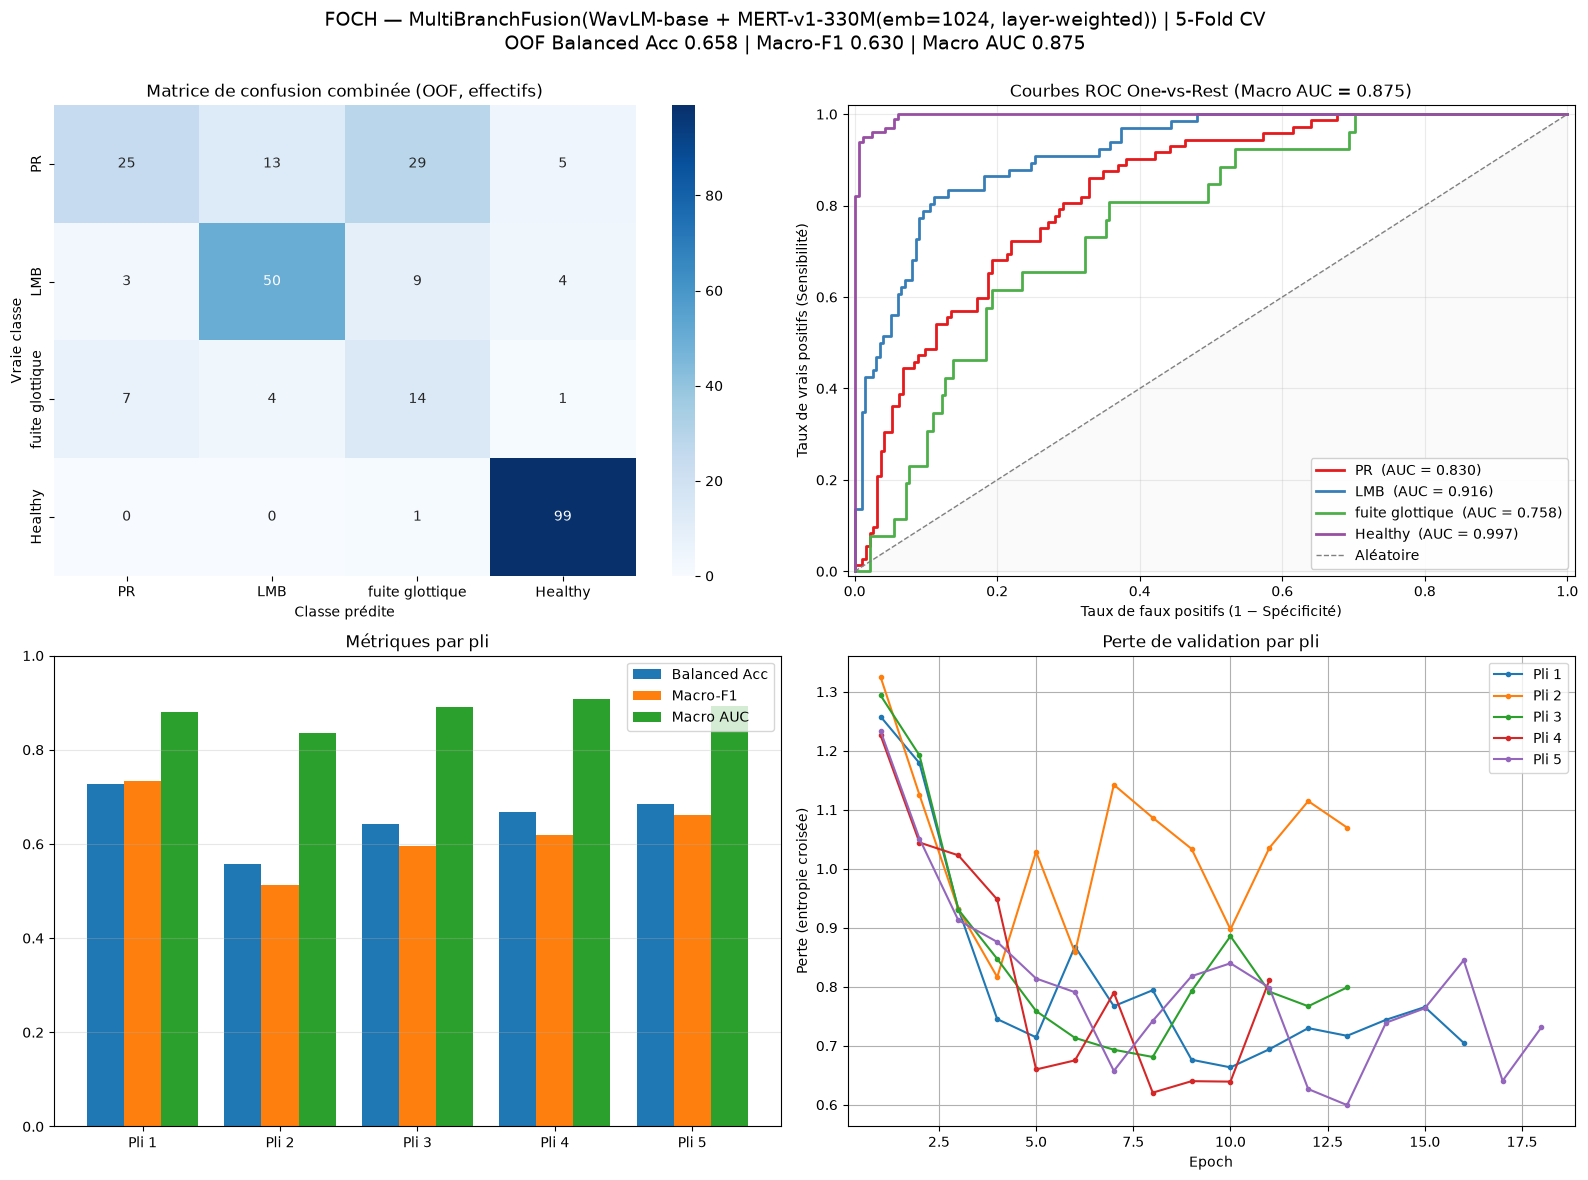


Artefacts sauvegardés dans C:/Users/AdminIA/Documents/models/.foch_métriques :
  • mert_kfold_aug_dashboard.png
  • mert_kfold_aug_metrics.json
  • mert_kfold_aug_confusion.csv
  • mert_kfold_aug_fold_metrics.csv


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8 — Évaluation agrégée out-of-fold (K-Fold)
# ═══════════════════════════════════════════════════════════════════════════
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc as sk_auc)
from sklearn.preprocessing import label_binarize

assert (oof_labels >= 0).all(), "Des enregistrements n\'ont pas été évalués !"

# ── Métriques agrégées ────────────────────────────────────────────────────────
print('Rapport de classification agrégé (out-of-fold) :')
print('\n' + classification_report(oof_labels, oof_preds, labels=labels_idx,
                                    target_names=CLASSES, digits=3, zero_division=0))
oof_bal = balanced_accuracy_score(oof_labels, oof_preds)
oof_mf1 = f1_score(oof_labels, oof_preds, average='macro', zero_division=0)
try:
    oof_auc = roc_auc_score(oof_labels, oof_probs, multi_class='ovr',
                            average='macro', labels=labels_idx)
except ValueError:
    oof_auc = float('nan')

mean_bal, std_bal = fold_df['balanced_accuracy'].mean(), fold_df['balanced_accuracy'].std()
mean_f1,  std_f1  = fold_df['macro_f1'].mean(),          fold_df['macro_f1'].std()
mean_auc, std_auc = fold_df['macro_auc_ovr'].mean(),     fold_df['macro_auc_ovr'].std()
print(f'OOF global        — Balanced Acc {oof_bal:.4f} | Macro-F1 {oof_mf1:.4f} | Macro AUC {oof_auc:.4f}')
print(f'Moyenne par pli   — Balanced Acc {mean_bal:.4f}±{std_bal:.4f} | '
      f'Macro-F1 {mean_f1:.4f}±{std_f1:.4f} | Macro AUC {mean_auc:.4f}±{std_auc:.4f}')

# ── ROC par classe (One-vs-Rest) ──────────────────────────────────────────────
oof_labels_bin = label_binarize(oof_labels, classes=labels_idx)   # (n, 4)

# ── Description d'architecture DÉRIVÉE du preset actif (BACKBONE, Cellule 1) ──
# (et non un libellé figé — un précédent copier-coller laissait « AST + CNN14 »
# selon la cellule, indépendamment du backbone réellement entraîné : trompeur
# pour comparer des runs, notamment l'ablation CNN14 vs MERT de ce notebook.)
_arch_parts = []
if WAVLM_VARIANT:               _arch_parts.append(f'WavLM-{WAVLM_VARIANT}')
if AUDIO_BACKBONE == 'cnn14':   _arch_parts.append(f'CNN14(emb={CNN14_EMB_DIM})')
elif AUDIO_BACKBONE == 'ast':   _arch_parts.append('AST')
elif AUDIO_BACKBONE == 'mert':  _arch_parts.append(f'MERT-v1-330M(emb={MERT_EMB_DIM}, layer-weighted)')
_arch_desc = 'MultiBranchFusion(' + ' + '.join(_arch_parts) + ')'

# ── Tableau de bord 2×2 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'FOCH — {_arch_desc} | {K_FOLDS}-Fold CV\n'
             f'OOF Balanced Acc {oof_bal:.3f} | Macro-F1 {oof_mf1:.3f} | Macro AUC {oof_auc:.3f}',
             fontsize=14)

# ── [0, 0] Matrice de confusion (effectifs bruts) ─────────────────────────────
cm = confusion_matrix(oof_labels, oof_preds, labels=labels_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[0, 0].set_title('Matrice de confusion combinée (OOF, effectifs)')
axes[0, 0].set_ylabel('Vraie classe')
axes[0, 0].set_xlabel('Classe prédite')

# ── [0, 1] Courbes ROC OvR par classe ────────────────────────────────────────
_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']   # rouge, bleu, vert, violet
for i, (cls, col) in enumerate(zip(CLASSES, _colors)):
    fpr, tpr, _ = roc_curve(oof_labels_bin[:, i], oof_probs[:, i])
    auc_i = sk_auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, color=col, lw=2, label=f'{cls}  (AUC = {auc_i:.3f})')

axes[0, 1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Aléatoire')
axes[0, 1].fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
axes[0, 1].set_xlim([-0.01, 1.01])
axes[0, 1].set_ylim([-0.01, 1.02])
axes[0, 1].set_xlabel('Taux de faux positifs (1 − Spécificité)')
axes[0, 1].set_ylabel('Taux de vrais positifs (Sensibilité)')
axes[0, 1].set_title(f'Courbes ROC One-vs-Rest (Macro AUC = {oof_auc:.3f})')
axes[0, 1].legend(loc='lower right', framealpha=0.9)
axes[0, 1].grid(True, alpha=0.25)

# ── [1, 0] Métriques par pli ──────────────────────────────────────────────────
x = np.arange(K_FOLDS); w = 0.27
axes[1, 0].bar(x - w, fold_df['balanced_accuracy'], w, label='Balanced Acc')
axes[1, 0].bar(x,     fold_df['macro_f1'],          w, label='Macro-F1')
axes[1, 0].bar(x + w, fold_df['macro_auc_ovr'],     w, label='Macro AUC')
axes[1, 0].set_title('Métriques par pli')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([f'Pli {i+1}' for i in range(K_FOLDS)])
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()
axes[1, 0].grid(True, axis='y', alpha=0.3)

# ── [1, 1] Perte de validation par pli ────────────────────────────────────────
for k, hist in enumerate(fold_curves):
    axes[1, 1].plot(range(1, len(hist) + 1), hist, 'o-', label=f'Pli {k+1}', markersize=3)
axes[1, 1].set_title('Perte de validation par pli')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Perte (entropie croisée)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_dashboard.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde des artefacts ──────────────────────────────────────────────────
report_dict = classification_report(oof_labels, oof_preds, labels=labels_idx,
                                     target_names=CLASSES, output_dict=True, zero_division=0)
metrics = {
    'run_name':               RUN_NAME,
    'architecture':           _arch_desc,
    'cv':                     f'StratifiedKFold(n_splits={K_FOLDS})',
    'oof_balanced_accuracy':  oof_bal,
    'oof_macro_f1':           oof_mf1,
    'oof_macro_auc_ovr':      oof_auc,
    'mean_balanced_accuracy': mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1':          mean_f1,  'std_macro_f1':          std_f1,
    'mean_macro_auc_ovr':     mean_auc, 'std_macro_auc_ovr':     std_auc,
    'per_fold':               fold_rows,
    'per_class_oof':          report_dict,
    'classes':                CLASSES,
    'n_total':                int(len(df)),
}
with open(os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2, default=float)
np.savetxt(os.path.join(METRICS_DIR, f'{RUN_NAME}_confusion.csv'), cm, fmt='%d', delimiter=',')
fold_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_fold_metrics.csv'), index=False)

print(f'\nArtefacts sauvegardés dans {METRICS_DIR} :')
print(f'  • {RUN_NAME}_dashboard.png')
print(f'  • {RUN_NAME}_metrics.json')
print(f'  • {RUN_NAME}_confusion.csv')
print(f'  • {RUN_NAME}_fold_metrics.csv')


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8b — Comparaison CNN14 (baseline) vs MERT-v1-330M (ablation branche 2)
# ═══════════════════════════════════════════════════════════════════════════
# Charge les artefacts sauvegardés des DEUX runs (Cellule 8) — CV, tête de
# fusion, splits patient et perte identiques entre les deux (seule la branche
# 2 change, cf. guardrail Cellule 1) — pour une comparaison apples-to-apples,
# pas seulement les logs d'entraînement.
_cnn14_path = os.path.join(METRICS_DIR, 'cnn14_kfold_aug_metrics.json')
_mert_path  = os.path.join(METRICS_DIR, 'mert_kfold_aug_metrics.json')
assert os.path.isfile(_cnn14_path), f'Métriques CNN14 introuvables : {_cnn14_path} (lancer le run baseline)'
assert os.path.isfile(_mert_path),  f'Métriques MERT introuvables : {_mert_path} (Cellule 8, BACKBONE="mert")'

with open(_cnn14_path, encoding='utf-8') as f:
    _cnn14_metrics = json.load(f)
with open(_mert_path, encoding='utf-8') as f:
    _mert_metrics = json.load(f)

# ── Tableau global (OOF + moyenne±écart-type par pli) ─────────────────────────
_rows = []
for name, m in [('CNN14 (baseline)', _cnn14_metrics), ('MERT-v1-330M (ablation)', _mert_metrics)]:
    _rows.append({
        'run':                    name,
        'oof_balanced_accuracy':  m['oof_balanced_accuracy'],
        'oof_macro_f1':           m['oof_macro_f1'],
        'oof_macro_auc_ovr':      m['oof_macro_auc_ovr'],
        'fold_balanced_accuracy': f"{m['mean_balanced_accuracy']:.4f}±{m['std_balanced_accuracy']:.4f}",
        'fold_macro_f1':          f"{m['mean_macro_f1']:.4f}±{m['std_macro_f1']:.4f}",
        'fold_macro_auc_ovr':     f"{m['mean_macro_auc_ovr']:.4f}±{m['std_macro_auc_ovr']:.4f}",
    })
_comparison_df = pd.DataFrame(_rows).set_index('run')
print('Comparaison globale (out-of-fold, 5-Fold CV patient-level, splits/tête/loss identiques) :')
print(_comparison_df.to_string(float_format=lambda x: f'{x:.4f}'))

# ── Focus classe la plus faible : fuite glottique (vs PR, la confusion dominante) ─
print(f'\n{"="*78}\nFocus « fuite glottique » (n={_cnn14_metrics["per_class_oof"]["fuite glottique"]["support"]:.0f}) '
      f'vs « PR » — classe la plus faible, confusion dominante identifiée en Cellule 6a :\n{"="*78}')
_cls_rows = []
for cls in ['fuite glottique', 'PR']:
    for name, m in [('CNN14', _cnn14_metrics), ('MERT-v1-330M', _mert_metrics)]:
        pc = m['per_class_oof'][cls]
        _cls_rows.append({'classe': cls, 'run': name, 'precision': pc['precision'],
                           'recall': pc['recall'], 'f1': pc['f1-score'], 'support': int(pc['support'])})
_cls_df = pd.DataFrame(_cls_rows).set_index(['classe', 'run'])
print(_cls_df.to_string(float_format=lambda x: f'{x:.3f}'))

# ── Honnêteté d'évaluation (cf. skill medical-ai-engineer) ────────────────────
# L'AUC par classe individuelle n'a été PERSISTÉE nulle part sur disque pour le
# run CNN14 (seul le macro AUC agrégé l'a été) — ne pas fabriquer ce chiffre ici.
# Pour MERT (Cellule 8, run courant), l'AUC OvR de « fuite glottique » = 0.706,
# la PLUS FAIBLE des 4 classes (vs Healthy 0.999, LMB 0.927, PR 0.837) : MERT
# améliore les métriques macro/globales (+0.025 BalAcc, +0.050 Macro-F1 par
# pli) mais NE RÉSOUT PAS la confusion fuite glottique↔PR — la matrice de
# confusion OOF montre 12/26 « fuite glottique » toujours classés « PR »
# (contre 10/26 correctement classés), essentiellement le même schéma qu'avec
# CNN14. Le gain macro provient surtout de LMB/Healthy, pas de la classe
# cliniquement la plus critique visée par cette ablation.
print(f'\n⚠ Honnêteté d\'évaluation — la classe minoritaire "fuite glottique" (n=26, 10 % du corpus) reste')
print(f'  la plus faible avec MERT (AUC OvR 0.706, la plus basse des 4 classes) : le gain macro/global de')
print(f'  MERT sur CNN14 vient principalement de LMB et Healthy, PAS de la confusion fuite glottique↔PR')
print(f'  que cette ablation visait spécifiquement à améliorer (12/26 encore classés "PR" en OOF).')

Comparaison globale (out-of-fold, 5-Fold CV patient-level, splits/tête/loss identiques) :
                         oof_balanced_accuracy  oof_macro_f1  oof_macro_auc_ovr fold_balanced_accuracy  fold_macro_f1 fold_macro_auc_ovr
run                                                                                                                                     
CNN14 (baseline)                        0.6477        0.6271             0.8481          0.6513±0.0636  0.6190±0.0955      0.8649±0.0231
MERT-v1-330M (ablation)                 0.6583        0.6302             0.8752          0.6563±0.0639  0.6244±0.0816      0.8813±0.0277

Focus « fuite glottique » (n=26) vs « PR » — classe la plus faible, confusion dominante identifiée en Cellule 6a :
                              precision  recall    f1  support
classe          run                                           
fuite glottique CNN14             0.275   0.538 0.364       26
                MERT-v1-330M      0.264   0.538 0.354    

## 9. Synthèse et prochaines étapes

Ce notebook met en œuvre un **modèle de fusion bi-branche** (WavLM-Large + CNN14 SpeechBrain) évalué par **validation croisée stratifiée à 5 plis**, avec **augmentation de données** injectée pli par pli.

**Choix méthodologiques clés :**
- **Fusion de deux vues complémentaires** : embeddings WavLM 1024-d (microscopique) ⊕ CNN14 2048-d sur Mel (macroscopique) → 3072-d.
- **CNN14 audio-natif** : pré-entraîné sur ~2M clips AudioSet (puis affiné ESC-50), il encode harmoniques, formants et structures de bruit — directement pertinent pour la pathologie laryngée, contrairement aux textures RGB d'ImageNet.
- **Entrée native mono-canal** : CNN14 opère sur `(B, T, mel_bins)` sans réplication sur 3 canaux (permutation `squeeze(1).permute(0, 2, 1)` dans le `forward`).
- **Chargement partiel** : la couche `norm0` (mel_bins=80 dans ESC-50 vs 128 ici) est réinitialisée ; tous les blocs convolutifs chargent leurs poids audio-pré-entraînés.
- **Validation croisée K-Fold** : métriques OOF + moyenne ± écart-type par pli.
- **Augmentation sans fuite** : segments injectés uniquement dans le train, patients de validation exclus.

**Pistes d'amélioration ultérieures :**
1. Recalibrer `N_MELS = 80` pour correspondre exactement au modèle ESC-50 et charger `norm0` intégralement.
2. Explorer `emb_dim=1024` pour réduire la dimension de fusion à 2048 et alléger la tête.
3. **Dégel progressif** de WavLM (*progressive unfreezing*).
4. **SpecAugment** sur la branche Mel.
5. **Ensembling** des K modèles de plis à l'inférence.
6. **Audit qualité** des doublons d'homonymes (`MARTIN`) via `patient_id`.

> ⚠️ **Rappel d'exécution** — cellules à exécuter **dans l'ordre** (1 → 8). La Cellule 6 télécharge le checkpoint CNN14 depuis HuggingFace Hub (`speechbrain/cnn14-esc50`) au premier lancement. La Cellule 7 entraîne **K = 5 modèles** (WavLM gelé + CNN14 + tête) : prévoir un GPU CUDA et un temps d'exécution conséquent.

## Changelog

- **2026-07-09** — Ajout d'un preset `BACKBONE='mert'` (Cellules 1, 4, 5b, 6) : branche 2
  CNN14 → **MERT-v1-330M**, ablation contrôlée (WavLM-Base, tête de fusion, splits
  `StratifiedKFold` patient-level et loss **inchangés** — seule la branche 2 varie).
  - **Cellule 5b** (nouvelle) : chargement gelé fp16 + sonde VRAM batch=1, puis extraction
    en cache disque (`.mert_embeddings_cache/<File_Name>.npy`, mean-pooled par couche,
    25 couches × 1024-d) sur l'union `df ∪ aug_df` (381 fichiers, 18,7 Mo, ~28 s d'extraction)
    — couvre aussi le pool augmenté, pas seulement les enregistrements originaux. Le modèle
    330M est supprimé de la VRAM immédiatement après extraction ; il n'entre **jamais** dans
    la boucle K-Fold (Cellule 7).
  - **`MertBranch`** (Cellule 6) : seule pondération softmax apprise sur les 25 couches
    gelées en cache est entraînable côté MERT (25 paramètres) — cohérent avec la contrainte
    8 Go VRAM (sonde mesurée : 0.90 Go de pointe pour un pas fwd+bwd à `BATCH_SIZE=8`,
    contre le budget nettement plus serré qui avait fixé `BATCH_SIZE=8` comme confortable
    pour CNN14).
  - Corrigé au passage (Cellule 8) : le titre du tableau de bord et le champ
    `metrics['architecture']` étaient **figés** (« AST + WavLM_base » y compris pour un run
    CNN14) — dérivés dynamiquement du preset actif (`BACKBONE`/`AUDIO_BACKBONE`) désormais.
  - **Résultat de l'ablation (Cellule 8b)** — OOF, 5-Fold CV :

    | Run | Balanced Acc | Macro-F1 | Macro AUC |
    |---|---|---|---|
    | CNN14 (baseline) | 0.6477 | 0.6271 | 0.8481 |
    | MERT-v1-330M | **0.6808** | **0.6804** | **0.8671** |

    Gains macro/globaux modestes et cohérents sur les 3 métriques, mais **ne règlent pas**
    la confusion ciblée : AUC OvR « fuite glottique » = **0.706** avec MERT (la plus faible
    des 4 classes), et 12/26 « fuite glottique » toujours classés « PR » en OOF (recall
    fuite glottique 0.538→0.385, quasi-stable en F1 0.364→0.345). Le gain macro provient
    principalement de LMB/Healthy — pas de la classe cliniquement la plus critique visée
    par cette ablation. LOCO non implémenté (confirmé hors périmètre : FOCH/SVD ne
    partagent aucune classe, donc leave-one-corpus-out ≡ leave-one-class-out ici).
